# Reproducing Figures 2 and 3

This notebook contains the code and data required to reproduce Figures 2 and 3 of the paper.

Two independent reproduction options are provided:

### Option 1 - Use the supplied equilibrium results

This is the recommended and fastest option.

The equilibrium results used to generate Figures 2 and 3 are loaded from the accompanying `simulation_data` directory, and the two figures are generated directly.

To use this option, run:

1. **Figure-generation functions**
2. **Option 1 - Reproduce the figures from the supplied equilibrium results**

### Option 2 - Recompute the figures from scratch

This option reproduces the complete computational workflow underlying the figures.

The equilibrium calculations and all eight 600 × 600 parameter sweeps are recomputed from the model, after which Figures 2 and 3 are generated from the newly computed results.

To use this option, run:

1. **Figure-generation functions**
2. **Option 2 - Recompute the figures from scratch**

The two options are independent. It is not necessary to run Option 1 before Option 2.

## Requirements

The notebook was tested with **Python 3.12.7** and requires the following packages:

- NumPy
- Matplotlib
- Seaborn
- SciPy
- Joblib
- tqdm

The required packages can be installed with:

`pip install numpy matplotlib seaborn scipy joblib tqdm`

# Figure-generation functions

This section defines the functions used to construct Figures 2 and 3.

These functions are independent of how the equilibrium results are obtained and are therefore used by both reproduction options.

In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# Plotting configuration
# ============================================================

DEFAULT_PANEL_CONFIG = {

    # Heatmap
    "cmap": "rocket",
    "vmin": 0,
    "vmax": 1,
    "square": True,

    # Ticks
    "x_ticks": 6,
    "y_ticks": 6,
    "tick_decimals": 2,
    "tick_fontsize": 12,

    # Axis labels
    "xlabel": None,
    "ylabel": None,
    "axis_label_fontsize": 15,

    # Border
    "axis_border_width": 2,

    # Title
    "title": None,
    "title_fontsize": 18,

    # Colorbar
    "colorbar": True,
    "colorbar_title": r"$A~frequency$",
}


DEFAULT_THEORY_CONFIG = {

    "color_1": "C0",
    "color_2": "C2",

    "linewidth": 2.5,

    "spacing": 0.005,
    "eps": 1e-12,

    # None = use the heatmap x-axis resolution.
    # An integer sets the analytical curve resolution explicitly.
    "theory_curve_points": None,

    "fill_color": "lightgrey",
    "fill_hatch": "....",
    "fill_edgecolor": "black",
    "fill_linewidth": 0.8,
}


DEFAULT_GENE_STRIP_CONFIG = {

    # Heatmap
    "cmap": "rocket",
    "vmin": 0,
    "vmax": 1,

    # Top title
    "top_title": "Gen",
    "top_title_fontsize": 18,

    # Bottom label
    "bottom_label": r"$T=0$",
    "bottom_label_fontsize": 16,

    # Border
    "axis_border_width": 2,
}


DEFAULT_FOUR_PANEL_FIGURE_CONFIG = {

    # Figure
    "figsize": (10.5, 7.5),

    # Grid
    "height_ratios": [1.0, 0.06, 1.0],

    # Default panel-title size.
    # Individual panels may override this value.
    "panel_title_fontsize": 14,

    # Shared colorbar
    "colorbar_title_fontsize": 18,
    "colorbar_tick_fontsize": 14,

    # Figure margins
    "left": 0.07,
    "right": 0.90,
    "bottom": 0.08,
    "top": 0.90,

    # Panel letters
    "panel_letter_fontsize": 26,
    "panel_letter_fontweight": "medium",

    # Position when gene strips are shown
    "panel_letter_x_with_gene": -0.6,
    "panel_letter_y_with_gene": 1.15,

    # Position without gene strips
    "panel_letter_x_without_gene": -0.1,
    "panel_letter_y_without_gene": 1.08,
}

In [3]:
# ============================================================
# Display helpers
# ============================================================

def axis_name_to_label(axis_name):
    """
    Convert an internal parameter name to its figure label.
    """
    
    axis_labels = {
        "T": r"$Transmission~rate~(T)$",
        "pA": r"$Survival~of~A~(P_A)$",
        "ratio_tA_tB": r"$Transmission~ratio~(T_A/T_B)$",
    }

    return axis_labels.get(axis_name, axis_name)


def style_axis_border(ax, linewidth):
    """
    Apply a consistent border to a plotting axis.
    """
    for spine in ax.spines.values():
        spine.set(visible=True, lw=linewidth, edgecolor="black")
        

# ============================================================
# Panel construction
# ============================================================

def build_panel(data, config=None, overlay_function=None):
    """
    Build one figure panel from equilibrium-result data.

    Parameters
    ----------
    data : dict
        Equilibrium-result data containing the result matrix
        and the corresponding parameter definitions.

    config : dict or None
        Panel-specific plotting overrides.

    overlay_function : callable or None
        Optional analytical overlay associated with this panel.

    Returns
    -------
    dict
        Panel definition used by the figure-generation functions.
    """

    panel_config = DEFAULT_PANEL_CONFIG.copy()

    if config is not None:
        unknown_keys = set(config) - set(DEFAULT_PANEL_CONFIG)

        if unknown_keys:
            raise ValueError("Unknown panel configuration option(s): " + ", ".join(sorted(unknown_keys)))

        panel_config.update(config)

    return {
        "data": data,
        "config": panel_config,
        "overrides": set(config) if config is not None else set(),
        "overlay_function": overlay_function,
    }


# ============================================================
# Heatmap plotting
# ============================================================

def plot_heatmap_panel(ax, panel, colorbar=None, cbar_ax=None, show_y_axis=True):
    """
    Plot one equilibrium-result heatmap on an existing axis.

    This is the basic heatmap-drawing function used for all
    panels in Figures 2 and 3.
    """

    # Panel data
    data = panel["data"]
    config = panel["config"]
    matrix = data["matrix"]

    parameter_definition = data["parameter_definition"]
    x_definition = parameter_definition["axes"]["x"]
    y_definition = parameter_definition["axes"]["y"]

    x_name = x_definition["name"]
    y_name = y_definition["name"]
    x_axis = np.asarray(x_definition["values"])
    y_axis = np.asarray(y_definition["values"])

    # Colorbar
    if colorbar is None:
        colorbar = config["colorbar"]

    cmap = sns.color_palette(config["cmap"], as_cmap=True)

    sns.heatmap(
        matrix,
        ax=ax,
        cbar=colorbar,
        cbar_ax=cbar_ax if colorbar else None,
        cmap=cmap,
        square=config["square"],
        vmin=config["vmin"],
        vmax=config["vmax"],
    )

    ax.invert_yaxis()

    # Tick positions and values
    x_tick_positions = np.linspace(0, len(x_axis) - 1, config["x_ticks"])
    y_tick_positions = np.linspace(0, len(y_axis) - 1, config["y_ticks"])

    x_tick_values = np.around(np.linspace(x_axis.min(), x_axis.max(), config["x_ticks"]), decimals=config["tick_decimals"])
    y_tick_values = np.around(np.linspace(y_axis.min(), y_axis.max(), config["y_ticks"]), decimals=config["tick_decimals"])

    # X axis
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_values, rotation=0, fontsize=config["tick_fontsize"])

    # Y axis
    ax.set_yticks(y_tick_positions)

    if show_y_axis:
        ax.set_yticklabels(y_tick_values, rotation=0, fontsize=config["tick_fontsize"])
    else:
        ax.set_yticklabels([])

    # Axis labels
    xlabel = (
        axis_name_to_label(x_name)
        if config["xlabel"] is None
        else config["xlabel"]
    )
    ax.set_xlabel(xlabel, fontsize=config["axis_label_fontsize"])

    if show_y_axis:
        ylabel = (
            axis_name_to_label(y_name)
            if config["ylabel"] is None
            else config["ylabel"]
        )
        ax.set_ylabel(ylabel, fontsize=config["axis_label_fontsize"])
    else:
        ax.set_ylabel("")

    # Title
    if config["title"] is not None:
        ax.set_title(config["title"], fontsize=config["title_fontsize"])

    # Appearance
    style_axis_border(ax, linewidth=config["axis_border_width"])

    if config["square"]:
        ax.set_box_aspect(1)

    return ax

In [4]:
# ============================================================
# Analytical boundaries
# ============================================================

def compute_symmetric_theoretical_curves(T, mA_mB, mB1, delta, config=None):
    """
    Compute the analytical equilibrium boundaries for Figure 2.
    """

    if config is None:
        config = DEFAULT_THEORY_CONFIG

    eps = config["eps"]

    # Boundary B
    denominator_B = (T * mA_mB * mB1 * delta - T * mB1 - mA_mB * mB1 * delta)
    numerator_B = mA_mB * mB1 - mB1
    yB = np.divide(numerator_B, denominator_B, out=np.full_like(T, np.nan), where=np.abs(denominator_B) > eps)

    # Boundary A
    if delta != 0:
        sqrt_term = (T**2 * mB1**2 * delta**2 - 2 * T**2 * mB1**2 * delta + T**2 * mB1**2 - 2 * T * mA_mB * mB1 * mB1 * delta**2 + 2 * T * mA_mB * mB1 * mB1 + 2 * T * mB1**2 * delta - 2 * T * mB1**2 + (mA_mB * mB1)**2 * delta**2 - 2 * (mA_mB * mB1)**2 * delta + (mA_mB * mB1)**2 + 2 * mA_mB * mB1 * mB1 * delta - 2 * mA_mB * mB1 * mB1 + mB1**2)
        sqrt_term = np.maximum(sqrt_term, 0)
        yA = ((T * mB1 * delta - T * mB1 - mA_mB * mB1 * delta - mA_mB * mB1 + mB1) / (2 * mA_mB * mB1 * delta) + np.sqrt(sqrt_term) / (2 * mA_mB * mB1 * delta))

    else:
        denominator_A = T * mB1 + mA_mB * mB1 - mB1
        numerator_A = -(mA_mB * mB1 - mB1)
        yA = np.divide(numerator_A, denominator_A, out=np.full_like(T, np.nan), where=np.abs(denominator_A) > eps)

    # Keep only boundaries relevant to the plotted domain
    yB[(yB > 1) | (yB < -1)] = np.nan
    yA[(yA > 1) | (yA < -1)] = np.nan

    return yA, yB


def compute_asymmetric_theoretical_curves(T_ratio, mA_mB, mB1, delta, tB, config=None):
    """
    Compute the analytical equilibrium boundaries for Figure 3.
    """

    if config is None:
        config = DEFAULT_THEORY_CONFIG

    eps = config["eps"]

    # Boundary B
    denominator_B = (mA_mB * mB1 * T_ratio * tB * tB * delta - mA_mB * mB1 * T_ratio * tB * delta - mA_mB * mB1 * tB**2 * delta + 2 * mA_mB * mB1 * tB * delta - mA_mB * mB1 * delta - mB1 * T_ratio * tB)
    numerator_B = (mA_mB * mB1 * T_ratio * tB - mA_mB * mB1 * tB + mA_mB * mB1 - mB1)
    yB = np.divide(numerator_B, denominator_B, out=np.full_like(T_ratio, np.nan), where=np.abs(denominator_B) > eps)

    # Boundary A
    if delta != 0:
        sqrt_term = ((mA_mB * mB1)**2 * delta**2 - 2 * (mA_mB * mB1)**2 * delta + (mA_mB * mB1)**2 - 2 * (mA_mB * mB1) * mB1 * (T_ratio * tB) * delta + 2 * (mA_mB * mB1) * mB1 * (T_ratio * tB) - 2 * (mA_mB * mB1) * mB1 * tB * delta**2 + 2 * (mA_mB * mB1) * mB1 * tB * delta + 2 * (mA_mB * mB1) * mB1 * delta - 2 * (mA_mB * mB1) * mB1 + mB1**2 * (T_ratio * tB)**2 - 2 * mB1**2 * (T_ratio * tB) * tB * delta - 2 * mB1**2 * (T_ratio * tB) + mB1**2 * tB**2 * delta**2 + 2 * mB1**2 * tB * delta + mB1**2)
        sqrt_term = np.maximum(sqrt_term, 0)
        yA = (-((mA_mB * mB1) * delta + (mA_mB * mB1) + mB1 * (T_ratio * tB) - mB1 * tB * delta - mB1) / (2 * (mA_mB * mB1) * delta) + np.sqrt(sqrt_term) / (2 * (mA_mB * mB1) * delta))

    else:
        denominator_A = ((mA_mB * mB1) + mB1 * T_ratio * tB - mB1)
        numerator_A = -((mA_mB * mB1) + mB1 * T_ratio * tB - mB1 * tB - mB1)
        yA = np.divide(numerator_A, denominator_A, out=np.full_like(T_ratio, np.nan), where=np.abs(denominator_A) > eps)

    # Keep only boundaries relevant to the plotted domain
    yA[(yA > 1) | (yA < -1)] = np.nan
    yB[(yB > 1) | (yB < -1)] = np.nan

    return yA, yB


# ============================================================
# Analytical-boundary plotting
# ============================================================

def plot_theoretical_boundaries(ax, yA, yB, x_values, n, x_min, x_max, config=None):
    """
    Plot analytical boundaries and the hatched region between
    them on an existing heatmap axis.
    """

    if config is None:
        config = DEFAULT_THEORY_CONFIG

    # Convert analytical x values to heatmap coordinates
    x_plot = ((x_values - x_min) / (x_max - x_min)) * n
    valid_region = np.isfinite(yA) & np.isfinite(yB)

    # Boundary B
    ax.plot(x_plot, yB * n, color="white", linewidth=config["linewidth"])
    ax.plot(x_plot, yB * n, color=config["color_1"], linewidth=config["linewidth"] - 0.5)

    # Boundary A
    ax.plot(x_plot, yA * n, color="black", linewidth=config["linewidth"])
    ax.plot(x_plot, yA * n, color=config["color_2"], linewidth=config["linewidth"] - 0.8)

    # Hatched region
    ax.fill_between(
        x_plot,
        np.minimum(yA, 1) * n,
        np.minimum(yB, 1) * n,
        where=(yB > yA) & valid_region,
        color=config["fill_color"],
        hatch=config["fill_hatch"],
        edgecolor=config["fill_edgecolor"],
        linewidth=config["fill_linewidth"],
    )


# ============================================================
# Figure 2 analytical overlay
# ============================================================

def symmetric_theory_overlay(ax, panel):
    """
    Add the analytical equilibrium boundaries used in Figure 2.
    """

    # Panel data
    data = panel["data"]
    parameter_definition = data["parameter_definition"]
    matrix = data["matrix"]

    # X axis
    x_definition = parameter_definition["axes"]["x"]

    if x_definition["name"] != "T":
        raise ValueError("Figure 2 analytical overlay requires x-axis 'T'.")

    x_axis = np.asarray(x_definition["values"])

    # Fixed parameters
    fixed_params = parameter_definition["fixed_params"]
    mA1 = fixed_params["mA1"]
    mA2 = fixed_params["mA2"]
    mB1 = fixed_params["mB1"]
    mB2 = fixed_params["mB2"]

    # Derived parameters
    mA_mB = mA1 / mB1
    delta_A = mA2 / mA1
    delta_B = mB2 / mB1

    if not np.isclose(delta_A, delta_B):
        raise ValueError("Figure 2 analytical theory requires mA2/mA1 == mB2/mB1.")

    delta = delta_A

    # Analytical-curve resolution
    theory_curve_points = DEFAULT_THEORY_CONFIG["theory_curve_points"]

    if theory_curve_points is None:
        theory_curve_points = len(x_axis)

    T = np.linspace(x_axis.min(), x_axis.max(), theory_curve_points)

    # Compute and plot boundaries
    yA, yB = compute_symmetric_theoretical_curves(T=T, mA_mB=mA_mB, mB1=mB1, delta=delta)

    plot_theoretical_boundaries(ax=ax, yA=yA, yB=yB, x_values=T, n=matrix.shape[1], x_min=x_axis.min(), x_max=x_axis.max())


# ============================================================
# Figure 3 analytical overlay
# ============================================================

def asymmetric_theory_overlay(ax, panel):
    """
    Add the analytical equilibrium boundaries used in Figure 3.

    When boundary B exits the plotted domain, the hatched region
    continues to y = 1 while boundary A remains finite.
    """

    # Panel data
    data = panel["data"]
    parameter_definition = data["parameter_definition"]
    matrix = data["matrix"]

    # X axis
    x_definition = parameter_definition["axes"]["x"]

    if x_definition["name"] != "ratio_tA_tB":
        raise ValueError("Figure 3 analytical overlay requires x-axis 'ratio_tA_tB'.")

    x_axis = np.asarray(x_definition["values"])

    # Fixed parameters
    fixed_params = parameter_definition["fixed_params"]
    tB = fixed_params["tB"]
    mA1 = fixed_params["mA1"]
    mA2 = fixed_params["mA2"]
    mB1 = fixed_params["mB1"]
    mB2 = fixed_params["mB2"]

    # Derived parameters
    mA_mB = mA1 / mB1
    delta_A = mA2 / mA1
    delta_B = mB2 / mB1

    if not np.isclose(delta_A, delta_B):
        raise ValueError("Figure 3 analytical theory requires mA2/mA1 == mB2/mB1.")

    delta = delta_A

    # Analytical-curve resolution
    theory_curve_points = DEFAULT_THEORY_CONFIG["theory_curve_points"]

    if theory_curve_points is None:
        theory_curve_points = len(x_axis)

    T_ratio = np.linspace(x_axis.min(), x_axis.max(), theory_curve_points)

    # Compute analytical boundaries
    yA, yB = compute_asymmetric_theoretical_curves(T_ratio=T_ratio, mA_mB=mA_mB, mB1=mB1, delta=delta, tB=tB)

    # Convert analytical x values to heatmap coordinates
    n = matrix.shape[1]
    x_plot = ((T_ratio - x_axis.min()) / (x_axis.max() - x_axis.min())) * n

    # Boundary B
    ax.plot(x_plot, yB * n, color="white", linewidth=DEFAULT_THEORY_CONFIG["linewidth"])
    ax.plot(x_plot, yB * n, color=DEFAULT_THEORY_CONFIG["color_1"], linewidth=DEFAULT_THEORY_CONFIG["linewidth"] - 0.5)

    # Boundary A
    ax.plot(x_plot, yA * n, color="black", linewidth=DEFAULT_THEORY_CONFIG["linewidth"])
    ax.plot(x_plot, yA * n, color=DEFAULT_THEORY_CONFIG["color_2"], linewidth=DEFAULT_THEORY_CONFIG["linewidth"] - 0.8)

    # Hatched region
    yB_fill = np.copy(yB)

    # If boundary B leaves the plotted domain,
    # continue the fill to the upper edge.
    yB_fill[~np.isfinite(yB_fill)] = 1

    fill_mask = np.isfinite(yA) & (yB_fill > yA)

    ax.fill_between(
        x_plot,
        yA * n,
        yB_fill * n,
        where=fill_mask,
        interpolate=True,
        color=DEFAULT_THEORY_CONFIG["fill_color"],
        hatch=DEFAULT_THEORY_CONFIG["fill_hatch"],
        edgecolor=DEFAULT_THEORY_CONFIG["fill_edgecolor"],
        linewidth=DEFAULT_THEORY_CONFIG["fill_linewidth"],
    )

In [5]:
# ============================================================
# Figure 2 gene strips
# ============================================================

def plot_gene_strip(ax, panel, config=None):
    """
    Plot the gene-frequency strip used in Figure 2.

    The strip displays the first column of the equilibrium-result
    matrix, corresponding to T = 0.
    """

    # Configuration
    gene_config = DEFAULT_GENE_STRIP_CONFIG.copy()

    if config is not None:
        unknown_keys = set(config) - set(DEFAULT_GENE_STRIP_CONFIG)

        if unknown_keys:
            raise ValueError("Unknown gene-strip configuration option(s): " + ", ".join(sorted(unknown_keys)))

        gene_config.update(config)

    panel_config = panel["config"]

    # Panel data
    data = panel["data"]
    matrix = data["matrix"]
    parameter_definition = data["parameter_definition"]

    y_definition = parameter_definition["axes"]["y"]
    y_name = y_definition["name"]
    y_axis = np.asarray(y_definition["values"])

    # Gene-frequency vector at T = 0
    genes_vec = np.asarray(matrix[:, 0])
    genes_mat = np.repeat(genes_vec[:, None], 2, axis=1)

    # Heatmap
    cmap = sns.color_palette(gene_config["cmap"], as_cmap=True)

    sns.heatmap(
        genes_mat,
        ax=ax,
        cbar=False,
        cmap=cmap,
        xticklabels=False,
        yticklabels=False,
        vmin=gene_config["vmin"],
        vmax=gene_config["vmax"],
    )

    ax.invert_yaxis()

    # Y-axis ticks
    y_tick_positions = np.linspace(0, len(y_axis) - 1, panel_config["y_ticks"])
    y_tick_values = np.around(np.linspace(y_axis.min(), y_axis.max(), panel_config["y_ticks"]), decimals=panel_config["tick_decimals"])

    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_tick_values, rotation=0, fontsize=panel_config["tick_fontsize"])

    # Y-axis label
    ylabel = (
        axis_name_to_label(y_name)
        if panel_config["ylabel"] is None
        else panel_config["ylabel"]
    )

    ax.set_ylabel(ylabel, fontsize=panel_config["axis_label_fontsize"])

    # Gene-strip labels
    ax.set_title(gene_config["top_title"], fontsize=gene_config["top_title_fontsize"])

    ax.set_xlabel(gene_config["bottom_label"],fontsize=gene_config["bottom_label_fontsize"])

    # Border
    style_axis_border(ax, linewidth=gene_config["axis_border_width"])

    return ax


# ============================================================
# Figure 2 gene-strip analytical boundary
# ============================================================

def symmetric_gene_theory_overlay(ax, panel, config=None):
    """
    Add the analytical LRS boundary to a Figure 2 gene strip.

    At T = 0 there is no polymorphic region. The boundary marks
    the survival probability at which the lifetime reproductive
    success of A and B is equal.
    """

    if config is None:
        config = DEFAULT_THEORY_CONFIG

    # Panel data
    data = panel["data"]
    parameter_definition = data["parameter_definition"]
    matrix = data["matrix"]
    fixed_params = parameter_definition["fixed_params"]

    # Model parameters
    mA1 = fixed_params["mA1"]
    mA2 = fixed_params["mA2"]
    mB1 = fixed_params["mB1"]
    mB2 = fixed_params["mB2"]

    ratio = mA1 / mB1
    delta_A = mA2 / mA1
    delta_B = mB2 / mB1

    if not np.isclose(delta_A, delta_B):
        raise ValueError("Figure 2 gene-strip boundary requires mA2/mA1 == mB2/mB1.")

    delta = delta_A

    if np.isclose(delta, 0):
        raise ValueError("The finite T=0 LRS boundary used here requires delta > 0.")

    # LRS equality boundary
    pA_boundary = 1 / (delta * ratio) - 1 / delta

    # Convert to heatmap coordinates
    n_y = matrix.shape[0]
    y_upper = (pA_boundary + config["spacing"]) * n_y
    y_lower = (pA_boundary - config["spacing"]) * n_y

    # Visual representation of the boundary
    ax.axhline(y=y_upper, color="black", linewidth=config["linewidth"])
    ax.axhline(y=y_upper, color=config["color_2"], linewidth=config["linewidth"] - 0.8)
    ax.axhline(y=y_lower, color="white", linewidth=config["linewidth"])
    ax.axhline(y=y_lower, color=config["color_1"], linewidth=config["linewidth"] - 0.5)

In [6]:
# ============================================================
# Four-panel figure layout
# ============================================================

def add_panel_letter(ax, letter, show_gene_strips, config=None):
    """
    Add a panel letter (a-d) to a four-panel figure.
    """

    if config is None:
        config = DEFAULT_FOUR_PANEL_FIGURE_CONFIG

    if show_gene_strips:
        x_pos = config["panel_letter_x_with_gene"]
        y_pos = config["panel_letter_y_with_gene"]
    else:
        x_pos = config["panel_letter_x_without_gene"]
        y_pos = config["panel_letter_y_without_gene"]

    ax.text(x_pos, y_pos, letter, transform=ax.transAxes, fontsize=config["panel_letter_fontsize"], fontweight=config["panel_letter_fontweight"], va="bottom", ha="center")


def build_four_panel_figure_layout(show_gene_strips=True, config=None):
    """
    Create the 2x2 layout used for Figures 2 and 3.

    Figure 2 uses gene strips beside the heatmaps.
    Figure 3 uses heatmaps only.
    """

    figure_config = DEFAULT_FOUR_PANEL_FIGURE_CONFIG.copy()

    if config is not None:
        figure_config.update(config)

    # The layout values below were tuned to reproduce the
    # published Figures 2 and 3.
    #
    # Figure 2 includes gene-frequency strips, whereas Figure 3
    # contains only the main heatmaps. The two figures therefore
    # use different spacing and width ratios.

    # ========================================================
    # Figure 2 layout: with gene strips
    # ========================================================

    if show_gene_strips:
        width_ratios = [0.15, 1.0, 0.20, 0.15, 1.0, 0.30]
        wspace = 0.25
        hspace = 0.42
        colorbar_position = [0.90, 0.30, 0.035, 0.40]
        n_cols = 6

        axes_positions = {
            "a": {"gene": (0, 0), "heat": (0, 1)},
            "b": {"gene": (0, 3), "heat": (0, 4)},
            "c": {"gene": (2, 0), "heat": (2, 1)},
            "d": {"gene": (2, 3), "heat": (2, 4)},
        }

        spacer_columns = [2, 5]

    # ========================================================
    # Figure 3 layout: without gene strips
    # ========================================================

    else:
        width_ratios = [1.0, 0.05, 1.0, 0.18]
        wspace = 0
        hspace = 0.375
        colorbar_position = [0.88, 0.30, 0.035, 0.40]
        n_cols = 4

        axes_positions = {
            "a": {"heat": (0, 0)},
            "b": {"heat": (0, 2)},
            "c": {"heat": (2, 0)},
            "d": {"heat": (2, 2)},
        }

        spacer_columns = [1, 3]

    # --------------------------------------------------------
    # Figure and subplot grid
    # --------------------------------------------------------

    fig, axs = plt.subplots(
        3,
        n_cols,
        figsize=figure_config["figsize"],
        gridspec_kw={
            "width_ratios": width_ratios,
            "height_ratios": figure_config["height_ratios"],
            "wspace": wspace,
            "hspace": hspace,
        },
    )

    fig.subplots_adjust(
        left=figure_config["left"],
        right=figure_config["right"],
        bottom=figure_config["bottom"],
        top=figure_config["top"],
        wspace=wspace,
        hspace=hspace,
    )

    # Shared colorbar
    cbar_ax = fig.add_axes(colorbar_position)

    # Hide spacer row and columns
    for col in range(n_cols):
        axs[1, col].axis("off")

    for row in (0, 2):
        for col in spacer_columns:
            axs[row, col].axis("off")

    # Named axes
    axes_map = {}

    for panel_id, positions in axes_positions.items():
        axes_map[panel_id] = {}

        for axis_type, position in positions.items():
            row, col = position
            axes_map[panel_id][axis_type] = axs[row, col]

    return fig, axs, cbar_ax, axes_map


# ============================================================
# Four-panel figure construction
# ============================================================

def plot_four_panel_figure(panels, show_gene_strips=True, gene_overlays=None, dpi=330):
    """
    Construct and display Figure 2 or Figure 3.

    Parameters
    ----------
    panels : dict
        Panels a, b, c, and d.

    show_gene_strips : bool
        True for Figure 2 and False for Figure 3.

    gene_overlays : dict or None
        Optional analytical overlays for individual gene strips.
        Ignored when show_gene_strips=False.

    dpi : int
        Figure resolution in dots per inch.
    """

    # Validation
    required_panels = {"a", "b", "c", "d"}

    if set(panels) != required_panels:
        raise ValueError("panels must contain exactly: 'a', 'b', 'c', 'd'.")

    figure_config = DEFAULT_FOUR_PANEL_FIGURE_CONFIG

    # Layout
    fig, axs, cbar_ax, axes_map = build_four_panel_figure_layout(show_gene_strips=show_gene_strips)

    # Main heatmaps
    for panel_id in ("a", "b", "c", "d"):
        ax = axes_map[panel_id]["heat"]
        panel = panels[panel_id]

        # Multi-panel title size
        use_figure_title_fontsize = "title_fontsize" not in panel["overrides"]

        if use_figure_title_fontsize:
            original_title_fontsize = panel["config"]["title_fontsize"]
            panel["config"]["title_fontsize"] = figure_config["panel_title_fontsize"]

        # Heatmap
        plot_heatmap_panel(
            ax=ax,
            panel=panel,
            colorbar=(panel_id == "c"),
            cbar_ax=cbar_ax if panel_id == "c" else None,
            show_y_axis=not show_gene_strips,
        )

        # Analytical overlay
        overlay_function = panel["overlay_function"]

        if overlay_function is not None:
            overlay_function(ax=ax, panel=panel)

        # Restore panel configuration
        if use_figure_title_fontsize:
            panel["config"]["title_fontsize"] = original_title_fontsize

    # Figure 2 gene strips
    if show_gene_strips:
        for panel_id in ("a", "b", "c", "d"):
            gene_ax = axes_map[panel_id]["gene"]
            plot_gene_strip(ax=gene_ax, panel=panels[panel_id])

            if gene_overlays is not None and panel_id in gene_overlays:
                gene_overlay_function = gene_overlays[panel_id]

                if gene_overlay_function is not None:
                    gene_overlay_function(ax=gene_ax, panel=panels[panel_id])

    # Panel letters
    for panel_id in ("a", "b", "c", "d"):
        if show_gene_strips:
            letter_ax = axes_map[panel_id]["gene"]
        else:
            letter_ax = axes_map[panel_id]["heat"]

        add_panel_letter(ax=letter_ax, letter=panel_id, show_gene_strips=show_gene_strips, config=figure_config)

    # Shared colorbar
    cbar_ax.set_title(DEFAULT_PANEL_CONFIG["colorbar_title"] + "\n", fontsize=figure_config["colorbar_title_fontsize"])
    cbar_ax.tick_params(labelsize=figure_config["colorbar_tick_fontsize"])
    style_axis_border(cbar_ax, linewidth=DEFAULT_PANEL_CONFIG["axis_border_width"])

    # Display
    fig.set_dpi(dpi)
    plt.show()

    return fig, axes_map, cbar_ax

# Option 1 - Reproduce the figures from the supplied equilibrium results

This section reproduces Figures 2 and 3 directly from the supplied equilibrium results.

No equilibrium calculations or parameter sweeps are performed in this option.

In [7]:
# ============================================================
# Load supplied equilibrium results
# ============================================================

DATA_DIR = Path("simulation_data")


def load_equilibrium_results(filename):
    """
    Load equilibrium results supplied with the notebook.

    The original stored files contain:
        1. parameter-sweep definition
        2. computation metadata
        3. equilibrium-result matrix

    Only the parameter definition and result matrix are required
    for reproducing the figures.
    """

    filepath = DATA_DIR / filename

    with open(filepath, "rb") as file:
        stored_definition = pickle.load(file)

        # Computation metadata is not required for plotting.
        _ = pickle.load(file)
        matrix = pickle.load(file)

    parameter_definition = {
        "fixed_params": stored_definition["fixed_params"],
        "axes": stored_definition["axes"],
    }

    return {
        "matrix": matrix,
        "parameter_definition": parameter_definition,
    }


# ============================================================
# Figure 2 data
# ============================================================

fig2_a_data = load_equilibrium_results("fig2_a.pkl")
fig2_b_data = load_equilibrium_results("fig2_b.pkl")
fig2_c_data = load_equilibrium_results("fig2_c.pkl")
fig2_d_data = load_equilibrium_results("fig2_d.pkl")


# ============================================================
# Figure 3 data
# ============================================================

fig3_a_data = load_equilibrium_results("fig3_a.pkl")
fig3_b_data = load_equilibrium_results("fig3_b.pkl")
fig3_c_data = load_equilibrium_results("fig3_c.pkl")
fig3_d_data = load_equilibrium_results("fig3_d.pkl")

## Figure 2

In [8]:
# ============================================================
# Figure 2 panels
# ============================================================

fig2_panels = {
    "a": build_panel(
        data=fig2_a_data,
        config={
            "title": "Young-only reproduction,\nhigh cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "b": build_panel(
        data=fig2_b_data,
        config={
            "title": "Young-only reproduction,\nlow cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "c": build_panel(
        data=fig2_c_data,
        config={
            "title": "Young and old reproduction,\nhigh cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "d": build_panel(
        data=fig2_d_data,
        config={
            "title": "Young and old reproduction,\nlow cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),
}

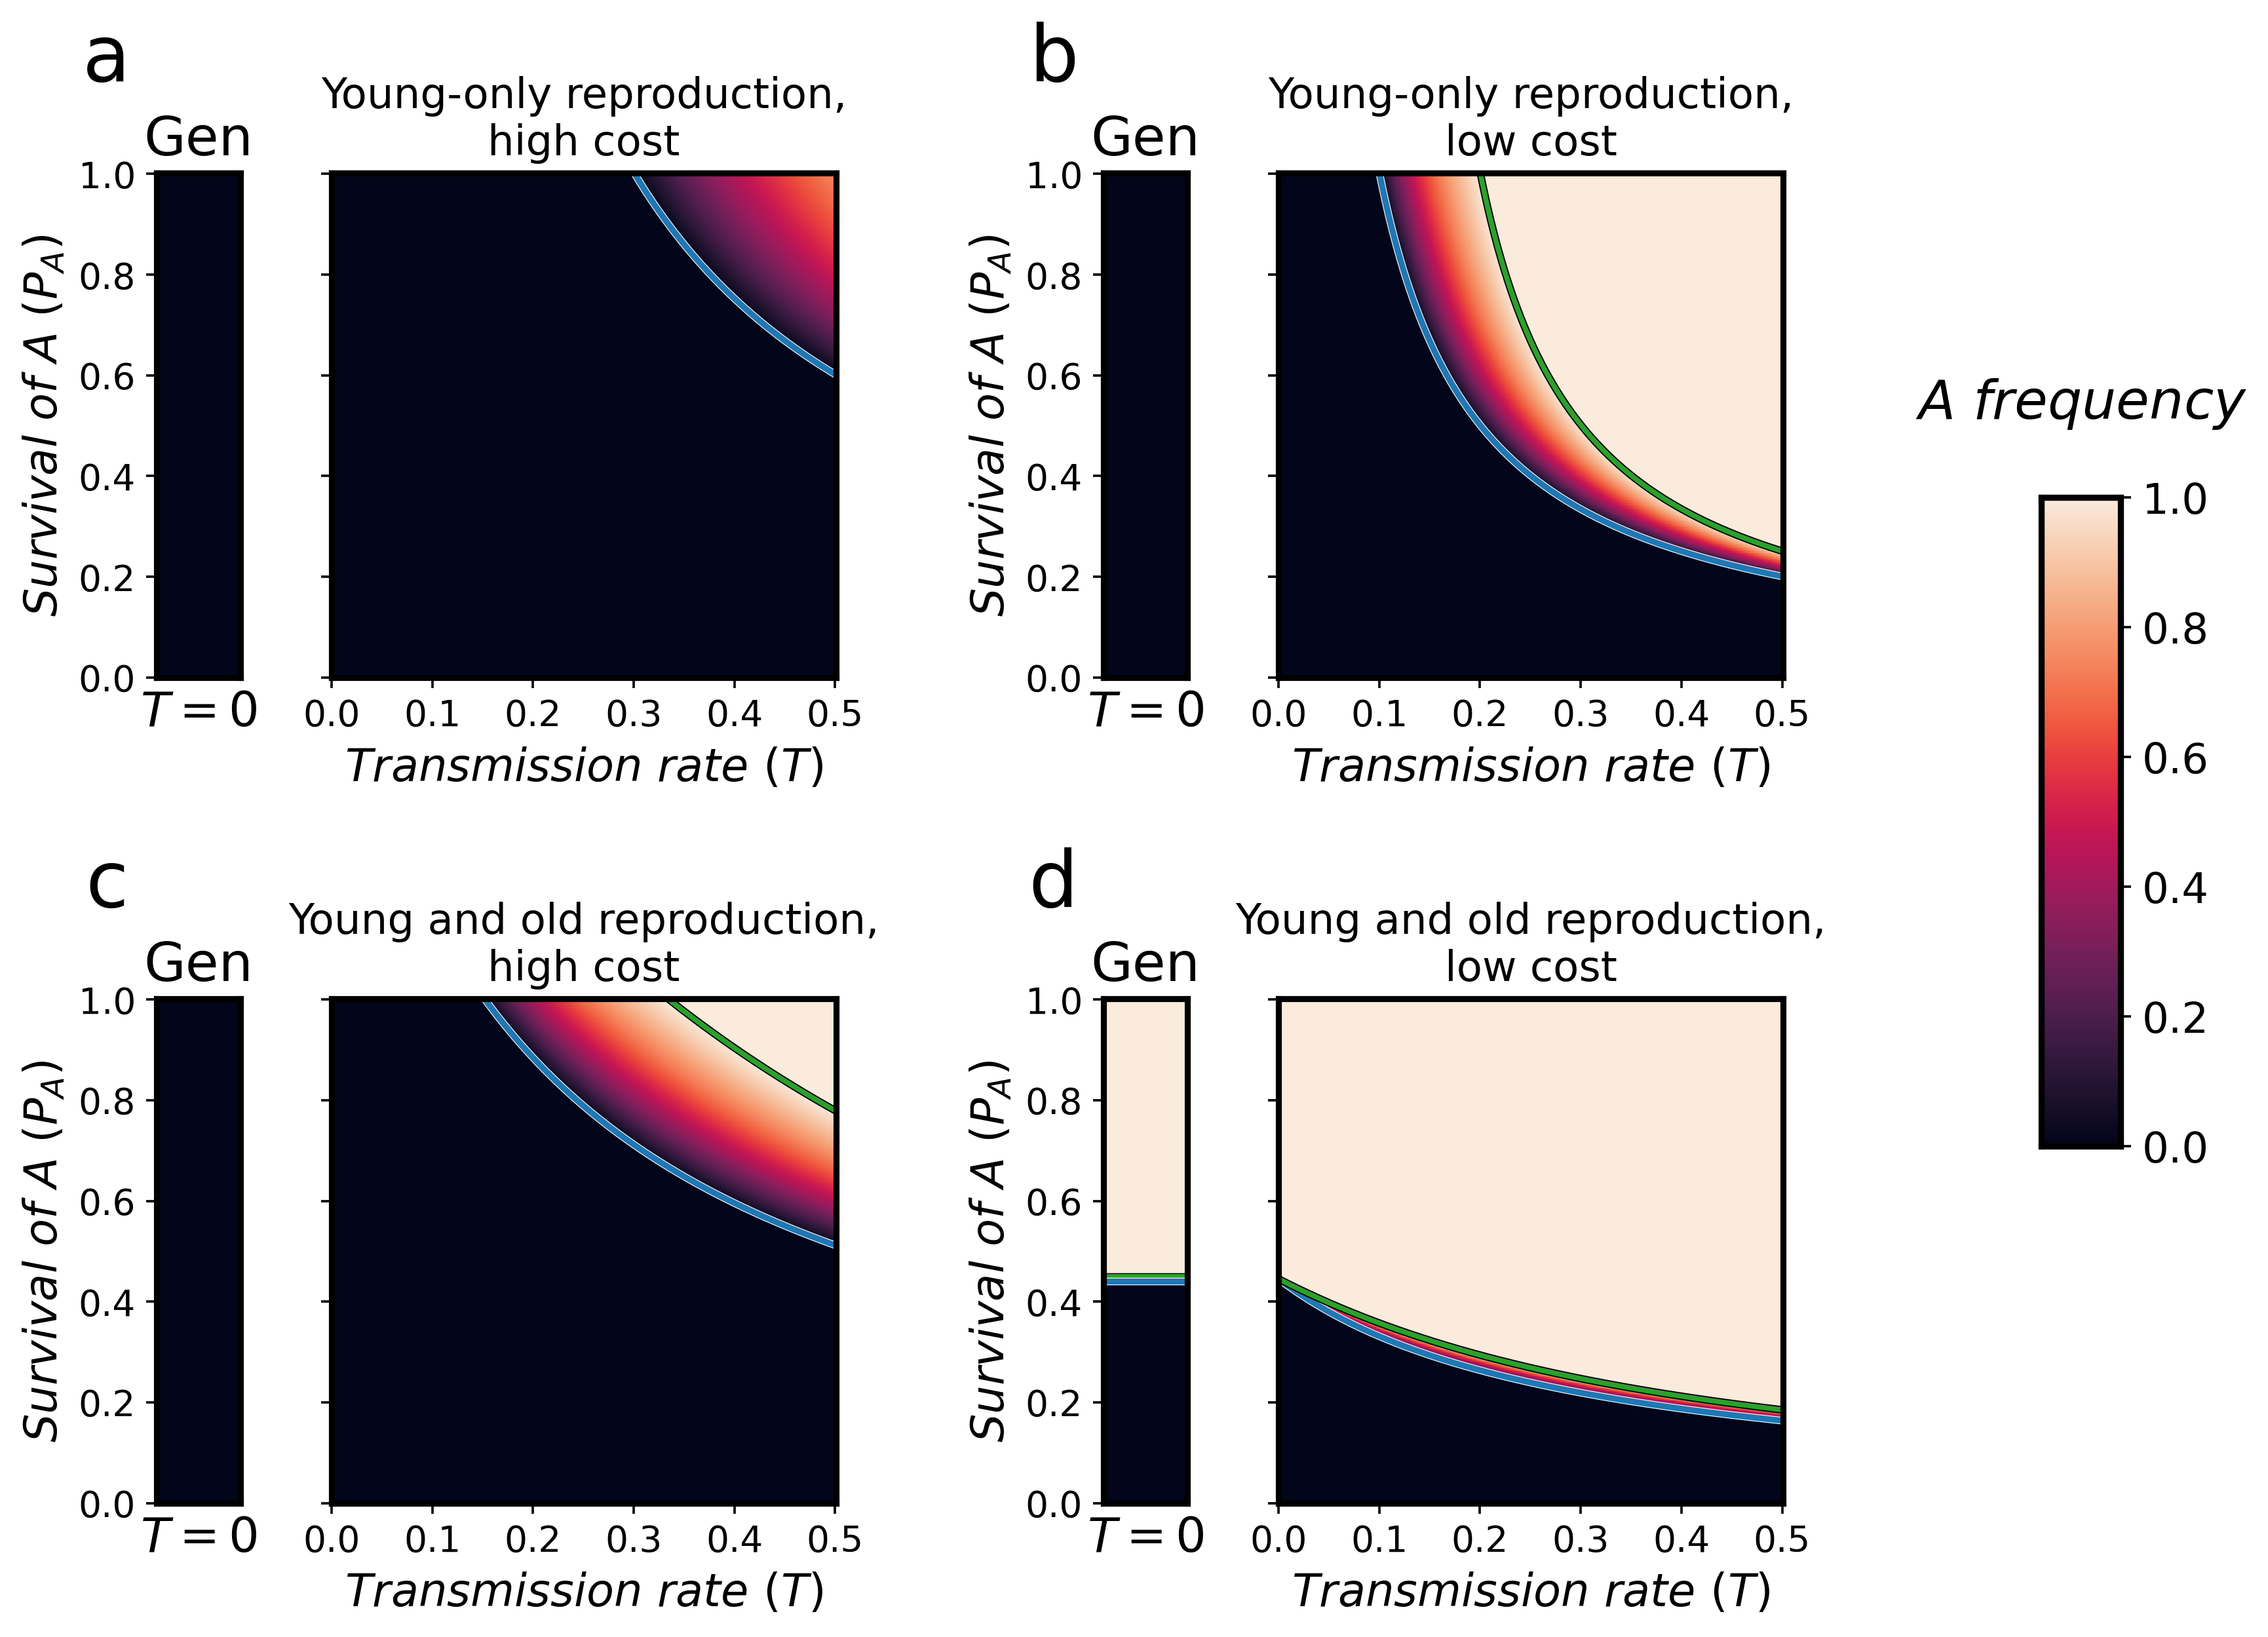

In [9]:
# ============================================================
# Plot Figure 2
# ============================================================

fig2, fig2_axes, fig2_colorbar = plot_four_panel_figure(
    panels=fig2_panels,
    show_gene_strips=True,
    gene_overlays={
        "c": symmetric_gene_theory_overlay,
        "d": symmetric_gene_theory_overlay,
    },
    dpi=330,
)

## Figure 3

In [10]:
# ============================================================
# Figure 3 panels
# ============================================================

fig3_panels = {
    "a": build_panel(
        data=fig3_a_data,
        config={
            "title": "Young-only reproduction,\nno reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "b": build_panel(
        data=fig3_b_data,
        config={
            "title": "Young-only reproduction,\nwith reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "c": build_panel(
        data=fig3_c_data,
        config={
            "title": "Young and old reproduction,\nno reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "d": build_panel(
        data=fig3_d_data,
        config={
            "title": "Young and old reproduction,\nwith reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),
}

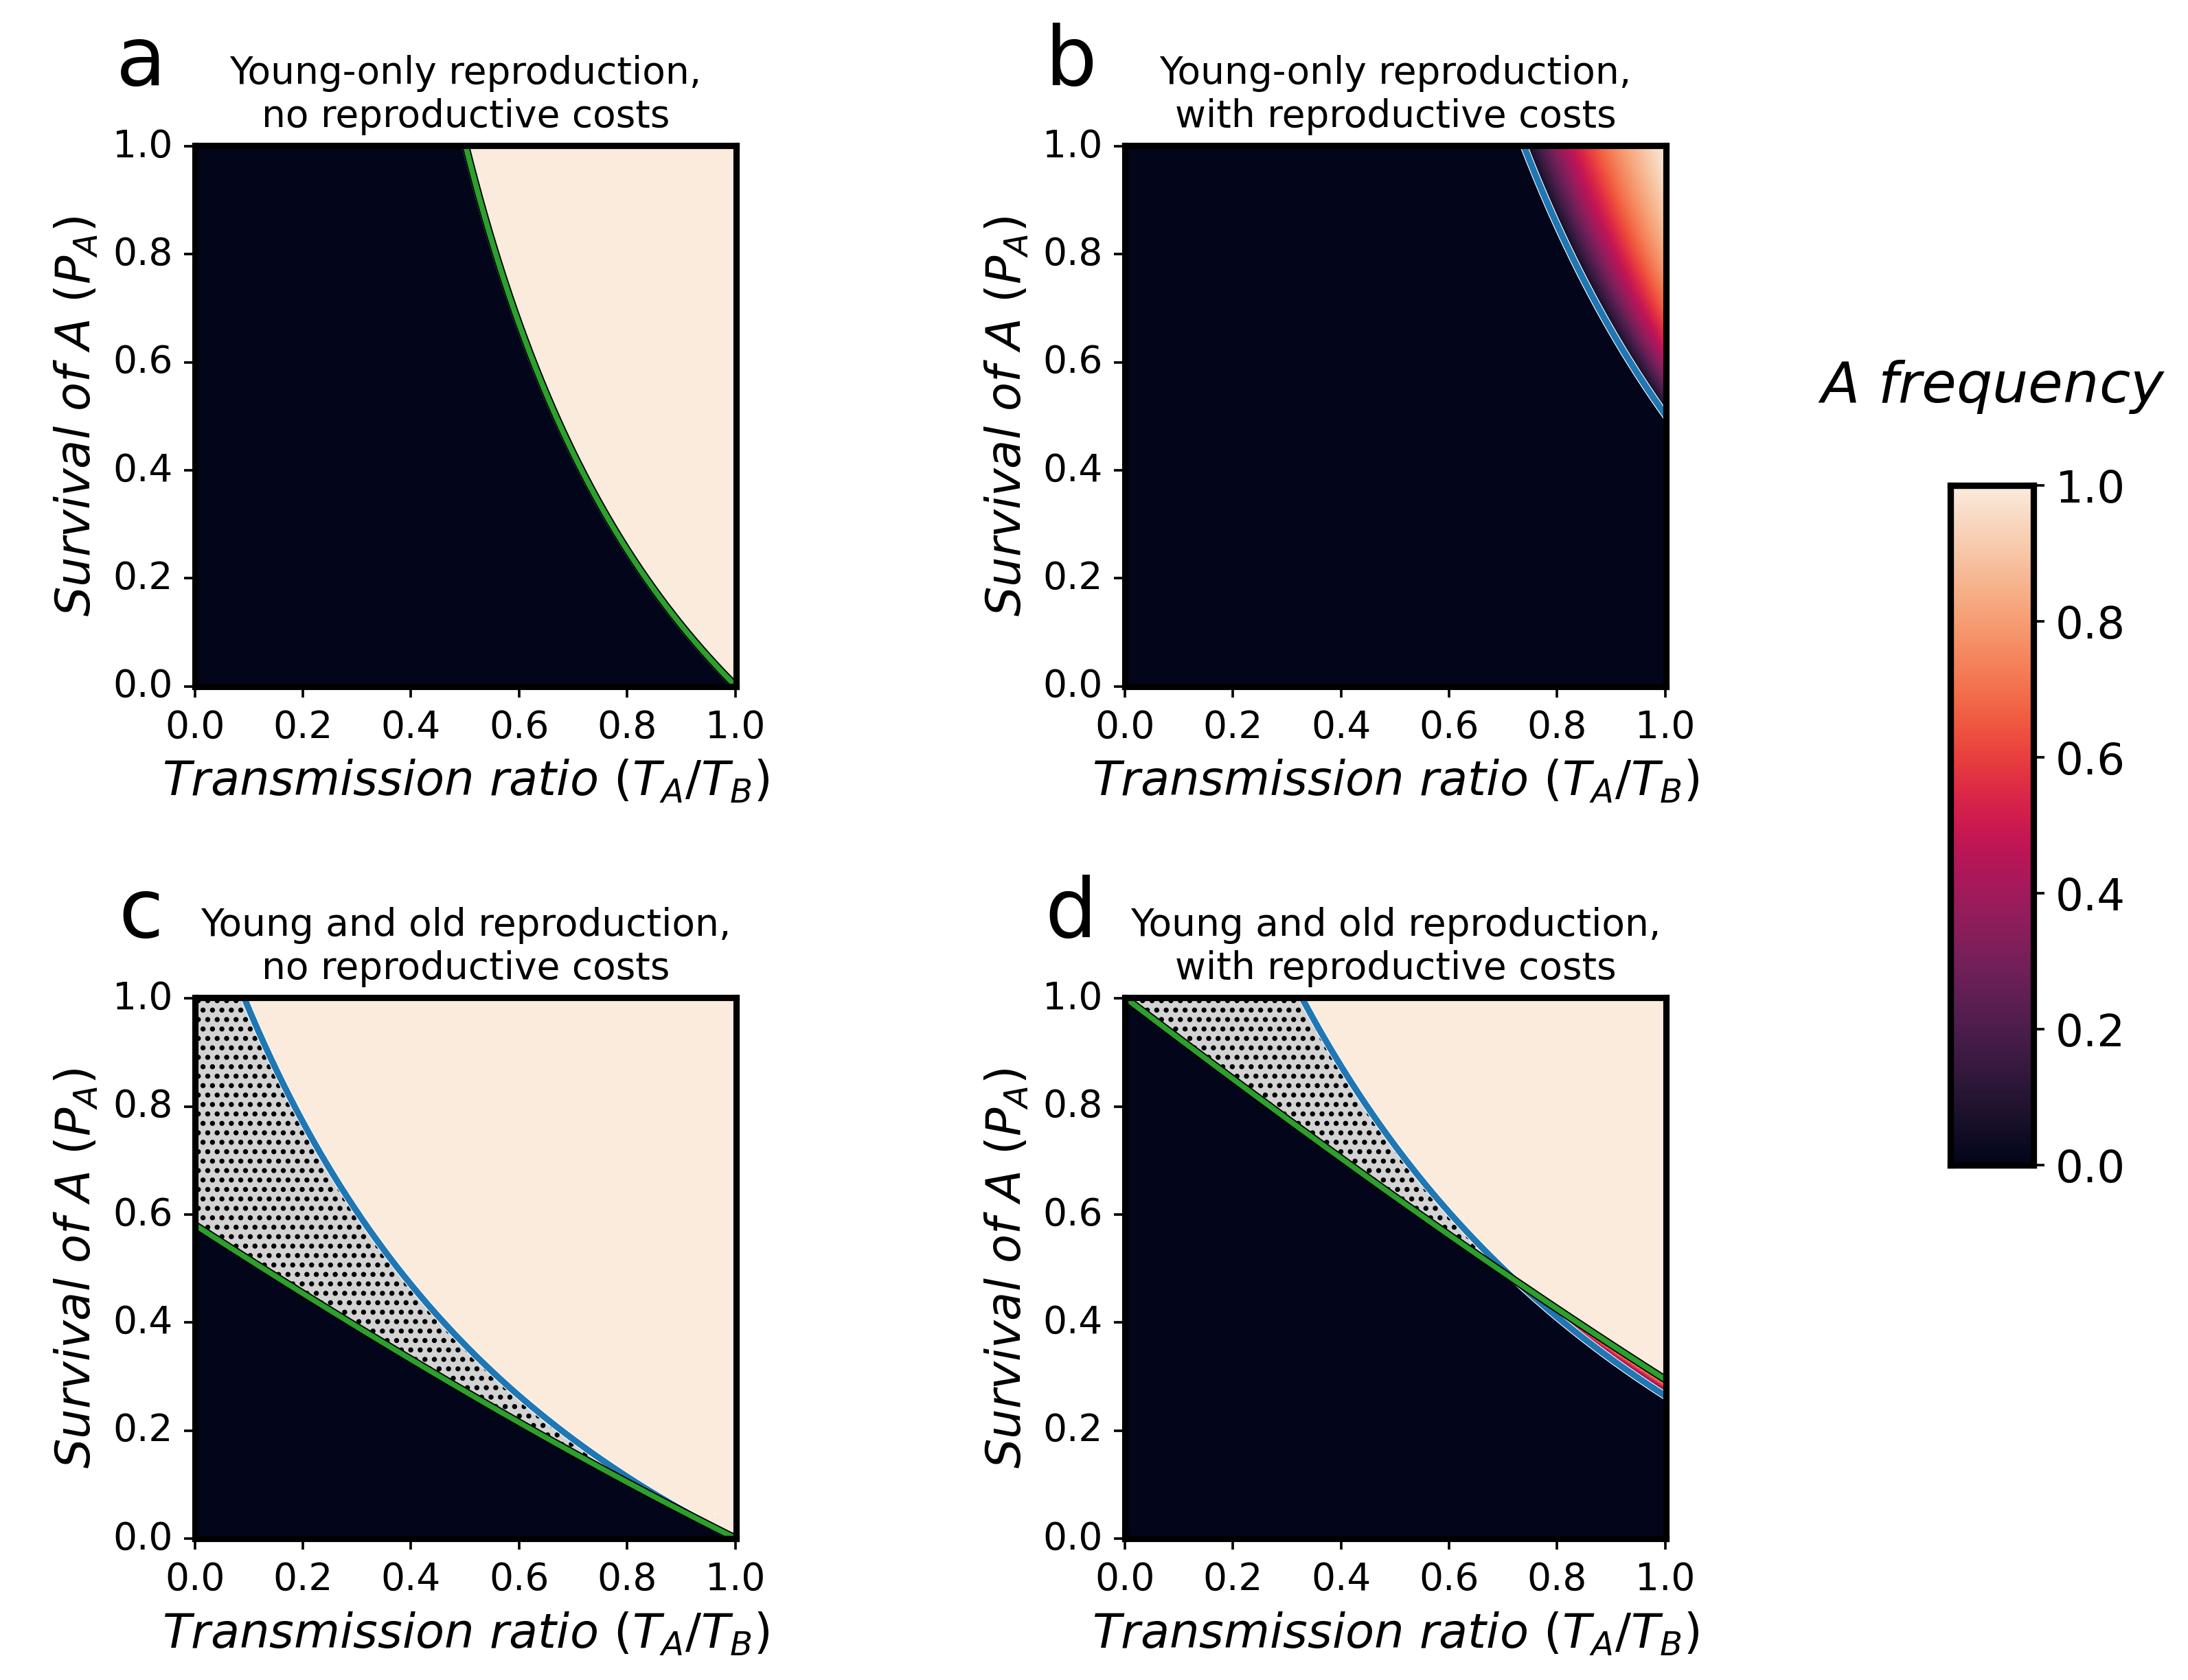

In [11]:
# ============================================================
# Plot Figure 3
# ============================================================

fig3, fig3_axes, fig3_colorbar = plot_four_panel_figure(
    panels=fig3_panels,
    show_gene_strips=False,
    dpi=330,
)

# Option 2 - Recompute the figures from scratch

This section reproduces Figures 2 and 3 by recomputing all equilibrium results from the model.

The required equilibrium calculations and parameter-sweep functions are defined below. No precomputed equilibrium results are used.

After the calculations are completed, the newly computed results are passed directly to the same figure-generation functions used in Option 1.

In [7]:
# ============================================================
# Additional imports for equilibrium calculations
# ============================================================

from itertools import product
from scipy.optimize import root
from joblib import Parallel, delayed
from tqdm import tqdm

In [8]:
# ============================================================
# Equilibrium utilities
# ============================================================

EPS = 1e-12
POLY_EPS = 1e-6


# ============================================================
# Numerical utilities
# ============================================================

def equal(x, y, eps=EPS):
    """
    Test numerical equality using absolute tolerance only.
    """
    
    return abs(x - y) < eps


def is_frequency(x, eps=EPS):
    """
    Test whether a value is a biologically admissible frequency.
    """
    
    return -eps < x < 1 + eps


def is_internal_frequency(x, eps=POLY_EPS):
    """
    Test whether a frequency is strictly internal.
    """
    
    return eps < x < 1 - eps


def validate_real(x, eps=EPS):
    """
    Validate that a numerical result represents a real value.

    Negligible imaginary parts are discarded. Genuinely
    non-real or invalid values raise ValueError.
    """
    
    if x is None:
        raise ValueError("Frequency is None")

    x = complex(x)

    if x.real != x.real or x.imag != x.imag:
        raise ValueError(f"NaN frequency detected: {x}")

    if abs(x.imag) <= eps:
        return float(x.real)

    raise ValueError(f"Non-real frequency detected: {x}")


def safe_div(num, den, eps=EPS):
    """
    Divide safely, returning NaN when the denominator is
    numerically zero.
    """
    
    if abs(complex(den)) < eps:
        return np.nan

    return num / den


# ============================================================
# Eigenvalue utilities
# ============================================================

def fast_eigenvalues_2x2(J):
    """
    Compute the eigenvalues of a 2x2 matrix.
    """
    
    a = J[0, 0]
    b = J[0, 1]
    c = J[1, 0]
    d = J[1, 1]

    trace = a + d
    determinant = a * d - b * c
    discriminant = trace**2 - 4 * determinant

    if discriminant >= 0:
        sqrt_discriminant = np.sqrt(discriminant)
    else:
        sqrt_discriminant = np.sqrt(complex(discriminant))

    lambda_1 = (trace + sqrt_discriminant) / 2
    lambda_2 = (trace - sqrt_discriminant) / 2

    return np.array([lambda_1, lambda_2])


def get_eigenvalues(eq):
    """
    Return the eigenvalues associated with an equilibrium.
    """
    
    if "eigenvalues" in eq:
        return eq["eigenvalues"]

    if "jacobian" in eq:
        J = eq["jacobian"]

        if J.shape == (2, 2):
            return fast_eigenvalues_2x2(J)

        return np.linalg.eigvals(J)

    raise ValueError("Equilibrium must contain either 'eigenvalues' or 'jacobian'.")


# ============================================================
# Equilibrium representation
# ============================================================

def add_equilibrium(equilibria, name, xA, internal=False, eigenvalues=None, jacobian=None):
    """
    Add an equilibrium using the common equilibrium structure.
    """
    
    if not np.isfinite(xA):
        return

    if eigenvalues is not None:
        if not all(np.isfinite(value) for value in eigenvalues):
            return

        equilibria.append(
            {
                "name": name,
                "xA": xA,
                "eigenvalues": eigenvalues,
                "internal": internal,
            }
        )

    elif jacobian is not None:
        if not np.all(np.isfinite(jacobian)):
            return

        equilibria.append(
            {
                "name": name,
                "xA": xA,
                "jacobian": jacobian,
                "internal": internal,
            }
        )

    else:
        raise ValueError("Must provide either 'eigenvalues' or 'jacobian'.")


# ============================================================
# Stable-equilibrium identification
# ============================================================

def analyze_equilibria(equilibria):
    """
    Return the unique biologically admissible stable equilibrium.

    NaN is returned if no stable equilibrium or more than one
    stable equilibrium is identified.
    """
    
    stable_states = []

    for eq in equilibria:
        try:
            xA = validate_real(eq["xA"])
        except (ValueError, TypeError):
            continue

        internal = eq.get("internal", False)
        eigenvalues = get_eigenvalues(eq)

        # Biological admissibility
        if internal:
            valid = is_internal_frequency(xA)
        else:
            valid = is_frequency(xA)

        if not valid:
            continue

        # Stability
        stable = np.all(np.abs(eigenvalues) < 1 + EPS)

        if not stable:
            continue

        stable_states.append(xA)

    # Require one unique stable equilibrium
    if len(stable_states) == 1:
        return stable_states[0]

    return np.nan

### Numerical calculation of polymorphic equilibria

For the general asymmetric case, polymorphic equilibria are obtained numerically when explicit analytical expressions are not available.

Candidate equilibria are located from multiple initial conditions within the biologically admissible state space. Their stability is subsequently evaluated together with the analytically obtained fixation equilibria.

In [9]:
# ============================================================
# ΔEquations of the general model
# ============================================================
def equilibrium_equations_general(vars, tA, tB, mA1, mA2, mB1, mB2, pA):
    """
    Implicit equilibrium equations for the general model.

    The general model makes no simplifying assumptions on the
    parameters, such as symmetric transmission or absence of
    late reproduction.

    Returns
    -------
    list
        Equilibrium residuals [ΔxA1, ΔxA2].
    """
    
    xA1, xA2 = vars
    ΔxA1 = -(xA1*(mA1*(tA*(xA1 + xA2)*(xA1 + xA2 - 1) - xA1*(tB*(xA1 + xA2 - 1) + 1)) - mA2*xA2*(tB*(xA1 + xA2 - 1) + 1) + mB1*(xA1 + xA2 - 1)*(-tA*(xA1 + xA2) + tB*xA1 + 1) + mB2*tB*xA2*(xA1 + xA2 - 1)) - (mA1*(tA*(xA1 + xA2)*(xA1 + xA2 - 1) - xA1*(tB*(xA1 + xA2 - 1) + 1)) - mA2*xA2*(tB*(xA1 + xA2 - 1) + 1))*(-tB*xA1*(xA1 + xA2 - 1) - tB*xA2*(xA1 + xA2 - 1) + xA2*(tB*(xA1 + xA2 - 1) + 1) + (pA - 1)*(tA*(xA1 + xA2)*(xA1 + xA2 - 1) + xA1*(-tB*(xA1 + xA2 - 1) - 1)) + (tA*(xA1 + xA2) - 1)*(xA1 + xA2 - 1)))/(mA1*(tA*(xA1 + xA2)*(xA1 + xA2 - 1) + xA1*(-tB*(xA1 + xA2 - 1) - 1)) - mA2*xA2*(tB*(xA1 + xA2 - 1) + 1) + mB1*(xA1 + xA2 - 1)*(-tA*(xA1 + xA2) + tB*xA1 + 1) + mB2*tB*xA2*(xA1 + xA2 - 1))
    ΔxA2 = -pA*(tA*(xA1 + xA2)*(xA1 + xA2 - 1) - xA1*(tB*(xA1 + xA2 - 1) + 1)) - xA2

    return [ΔxA1, ΔxA2]


# ============================================================
# Jacobian of the general model
# ============================================================
def jacobian_general(vars, tA, tB, mA1, mA2, mB1, mB2, pA):
    """
    Jacobian matrix corresponding to
    equilibrium_equations_general().
    """
    
    xA1, xA2 = vars
    J = np.array([[(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - 1)/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1)) + (mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1))*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - mA2*tB*xA2 - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) - 1) + mB2*tB*xA2)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1))**2 + (mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) + mA2*tB*xA2)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1)), (mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1)) + (mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1) - mA2*tB*xA2 - mA2*(-tB*(-xA1 - xA2 + 1) + 1) - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 - 1) + mB2*tB*xA2 - mB2*tB*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1))**2 + (mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1) + mA2*tB*xA2 + mA2*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-tB*(-xA1 - xA2 + 1) + 1) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)) + mB2*tB*xA2*(-xA1 - xA2 + 1))], [pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1), pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1)]])

    return J


# ============================================================
# Numerically finding polymorphic equilibria
# ============================================================

def make_polymorphism_guesses(n_subclasses, n_grid=10, boundary_eps=1e-4):
    """
    Generate initial guesses for the numerical polymorphism search.
    Guesses are distributed over the biologically feasible region:
        xA1 > 0
        xA2 > 0
        xA1 + xA2 < 1
    """
    
    guesses = []
    grid = np.linspace(boundary_eps, 1 - boundary_eps, n_grid)

    for point in product(grid, repeat=n_subclasses):
        if sum(point) < 1 - boundary_eps:
            guesses.append(list(point))

    return guesses


POLYMORPHISM_GUESSES = make_polymorphism_guesses(
    n_subclasses=2,
    n_grid=10,
)


def solve_polymorphism(params):
    """
    Numerically compute polymorphic equilibria.

    This function may return zero, one, or multiple candidate
    polymorphic equilibria. Stability is evaluated separately.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params

    poly_equilibria = []
    found = []
    guesses = POLYMORPHISM_GUESSES
    max_solutions = 2

    # Loop over initial guesses
    for guess in guesses:
        try:
            sol = root(
                equilibrium_equations_general,
                guess,
                args=(tA, tB, mA1, mA2, mB1, mB2, pA),
                jac=jacobian_general,
            )
        except (FloatingPointError, OverflowError, ValueError):
            continue

        # Solver failure
        if not sol.success:
            continue

        # Extract solution
        xA1_poly, xA2_poly = sol.x
        xA_poly = xA1_poly + xA2_poly

        # Biological admissibility
        valid_freq = (
            is_frequency(xA1_poly)
            and is_frequency(xA2_poly)
            and is_internal_frequency(xA_poly)
        )

        if not valid_freq:
            continue

        # Remove duplicate equilibria
        duplicate = any(np.allclose([xA1_poly, xA2_poly], prev, atol=1e-8, rtol=0) for prev in found)

        if duplicate:
            continue

        found.append([xA1_poly, xA2_poly])

        if len(found) >= max_solutions:
            break
        
        # Numerical Jacobian
        J = np.array([[(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1))*(tA*(xA1_poly + xA2_poly) - tA*(-xA1_poly - xA2_poly + 1) - tB*xA1_poly + tB*(-xA1_poly - xA2_poly + 1) + (1 - pA)*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly - tB*(-xA1_poly - xA2_poly + 1) + 1) - 1)/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1)) + (mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1))*(-mA1*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly - tB*(-xA1_poly - xA2_poly + 1) + 1) - mA2*tB*xA2_poly - mB1*(tA*(xA1_poly + xA2_poly) - tA*(-xA1_poly - xA2_poly + 1) - tB*xA1_poly + tB*(-xA1_poly - xA2_poly + 1) - 1) + mB2*tB*xA2_poly)*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + tB*xA2_poly*(-xA1_poly - xA2_poly + 1) + xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + (1 - pA)*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1))/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1))**2 + (mA1*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly - tB*(-xA1_poly - xA2_poly + 1) + 1) + mA2*tB*xA2_poly)*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + tB*xA2_poly*(-xA1_poly - xA2_poly + 1) + xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + (1 - pA)*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1))/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1)), (mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1))*(tA*(xA1_poly + xA2_poly) - tA*(-xA1_poly - xA2_poly + 1) - tB*xA1_poly + (1 - pA)*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly))/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1)) + (mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1))*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + tB*xA2_poly*(-xA1_poly - xA2_poly + 1) + xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + (1 - pA)*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1))*(-mA1*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly) - mA2*tB*xA2_poly - mA2*(-tB*(-xA1_poly - xA2_poly + 1) + 1) - mB1*(tA*(xA1_poly + xA2_poly) - tA*(-xA1_poly - xA2_poly + 1) - tB*xA1_poly - 1) + mB2*tB*xA2_poly - mB2*tB*(-xA1_poly - xA2_poly + 1))/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1))**2 + (mA1*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly) + mA2*tB*xA2_poly + mA2*(-tB*(-xA1_poly - xA2_poly + 1) + 1))*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + tB*xA2_poly*(-xA1_poly - xA2_poly + 1) + xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + (1 - pA)*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1))/(mA1*(tA*(xA1_poly + xA2_poly)*(-xA1_poly - xA2_poly + 1) + xA1_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1)) + mA2*xA2_poly*(-tB*(-xA1_poly - xA2_poly + 1) + 1) + mB1*(tB*xA1_poly*(-xA1_poly - xA2_poly + 1) + (-tA*(xA1_poly + xA2_poly) + 1)*(-xA1_poly - xA2_poly + 1)) + mB2*tB*xA2_poly*(-xA1_poly - xA2_poly + 1))], [pA*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly - tB*(-xA1_poly - xA2_poly + 1) + 1), pA*(-tA*(xA1_poly + xA2_poly) + tA*(-xA1_poly - xA2_poly + 1) + tB*xA1_poly)]], dtype=np.complex128)

        # Register equilibrium
        poly_equilibria.append(
            {
                "name": f"Polymorphism_{len(found)}",
                "xA": xA_poly,
                "jacobian": J,
                "internal": True,
            }
        )

    return poly_equilibria

### Analytical equilibrium cases

Different regions of parameter space require different equilibrium calculations.

For each parameter combination, the appropriate case is identified automatically. Candidate fixation and polymorphic equilibria are then constructed and evaluated for biological admissibility and stability.

All cases required across the parameter ranges of Figures 2 and 3 are included below.

In [10]:
# ============================================================
# Case classifier
# ============================================================

def identify_case(params):
    """
    Identify the equilibrium case corresponding to a parameter set.

    The returned case name determines which equilibrium calculation
    is used for that point in parameter space.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    genetic = (equal(tA, 0) and equal(tB, 0))
    sym = equal(tA, tB)
    δA_equal_0 = equal(mA2, 0)
    δB_equal_0 = equal(mB2, 0)
    δA_equal_1 = equal(mA2, mA1)
    δB_equal_1 = equal(mB2, mB1)

    # genetic
    if genetic:
        if δA_equal_0 and δB_equal_0:
            return "genetic_noδ"
        else:
            return "genetic_gen"

    # no δ
    elif δA_equal_0 and δB_equal_0:
        if sym:
            return "noδ_sym"
        else:
            return "noδ_Asym"

    # δ = 1
    elif δA_equal_1 and δB_equal_1:
        if sym:
            return "withδequal1_sym"
        else:
            return "withδ_Asym"

    # general δ
    else:
        if sym:
            return "withδ_sym"
        else:
            return "withδ_Asym"



# ============================================================
# Case registry
# ============================================================
CASES = {}


# Case 1: Genetic — general
# ============================================================
def equilibria_genetic_gen(params):
    """
    Generate equilibria for genetic_gen case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    equilibria = []
    
    # B fixation
    xA = 0
    λ1 = (mA1 - np.sqrt(mA1**2 + 4*mA2*mB1*pA + 0j))/(2*mB1)
    λ2 = (mA1 + np.sqrt(mA1**2 + 4*mA2*mB1*pA + 0j))/(2*mB1)
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = mB1/(mA1 + mA2*pA)
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    return equilibria
    
CASES["genetic_gen"] = equilibria_genetic_gen
# ============================================================


# Case 2: Genetic — no reproduction in old age
# ============================================================
def equilibria_genetic_noδ(params):
    """
    Generate equilibria for genetic_noδ case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    equilibria = []
    
    # B fixation
    xA = 0
    λ1 = 0
    λ2 = mA1/mB1
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)
    
    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = mB1/mA1
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)
    
    return equilibria

CASES["genetic_noδ"] = equilibria_genetic_noδ
# ============================================================


# Case 3: No reproduction in old age — symmetric transmission
# ============================================================
def equilibria_noδ_sym(params):
    """
    Generate equilibria for noδ_sym case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    T = tA
    equilibria = []
    
    # B fixation
    xA = 0
    λ1 = 0
    λ2 = (T*mB1*pA + mA1)/mB1
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = (-T*mB1*pA + mB1*pA + mB1)/(mA1*pA + mA1)
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # Polymorphism
    xA1 = -mA1*(T*mB1*pA + mA1 - mB1)/(T*mB1*pA*(T*mB1*pA + mA1 - mB1*pA - mB1))
    xA2 = (T*mB1*pA + mA1 - mB1)/(T*mB1*pA)
    xA = xA1 + xA2
    
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # eigenvalues
        λ1 = (2*mA1+mB1*(pA*T-2) + np.sqrt((4*(mA1-mB1)**3*(1+pA)+4*(mA1-mB1)**2*mB1*pA*(2+pA)*T-mB1**2*pA**2*(-5*mA1+mB1*(5 + pA))*T**2+mB1**3*pA**3*T**3)/(mA1+mB1*(-1+pA*(-1+T)))+ 0j))/(2*(mA1 - mB1))
        λ2 = (2*mA1+mB1*(pA*T-2) - np.sqrt((4*(mA1-mB1)**3*(1+pA)+4*(mA1-mB1)**2*mB1*pA*(2+pA)*T-mB1**2*pA**2*(-5*mA1+mB1*(5 + pA))*T**2+mB1**3*pA**3*T**3)/(mA1+mB1*(-1+pA*(-1+T)))+ 0j))/(2*(mA1 - mB1))
        
        add_equilibrium(equilibria, name="Polymorphism_1", xA=xA, eigenvalues=[λ1, λ2], internal=True)

    return equilibria

CASES["noδ_sym"] = equilibria_noδ_sym
# ============================================================


# Case 4: No reproduction in old age — asymmetric transmission
# ============================================================
def equilibria_noδ_Asym(params):
    """
    Generate equilibria for noδ_Asym case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    equilibria = []

    # B fixation
    xA = 0
    λ1 = 0
    λ2 = (mA1*tA - mA1*tB + mA1 + mB1*pA*tA)/mB1
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = (-mB1*pA*tA + mB1*pA - mB1*tA + mB1*tB + mB1)/(mA1*pA + mA1)
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # Polymorphism 1
    xA1 = safe_div((-mA1**2*tA + mA1**2*tB + mA1*mB1*pA*tA**2 - mA1*mB1*pA*tA*tB + mA1*mB1*pA*tB + mA1*mB1*tA - mA1*mB1*tB + mA1*tA*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) - mA1*tB*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) + mB1**2*pA**2*tA**2 - mB1**2*pA**2*tA - mB1**2*pA*tA + mB1*pA*tA*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j)),(2*mB1*pA*(mA1*tA*tB - mA1*tB**2 - mB1*pA*tA**2 + mB1*pA*tA*tB - mB1*tA**2 + mB1*tA*tB)))
    xA2 = safe_div((mA1**2 - mA1*mB1*pA*tA + 2*mA1*mB1*pA*tB - mA1*mB1*pA - 2*mA1*mB1 - mA1*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) - 2*mB1**2*pA**2*tA - mB1**2*pA*tA + mB1**2*pA + mB1**2 + mB1*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j)),(2*mA1*mB1*pA*tB - 2*mB1**2*pA**2*tA - 2*mB1**2*pA*tA))
    xA = xA1 + xA2
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # Jacobian matrix 
        J = np.array([[mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - 1)/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) - 1))*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2, mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1) - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 - 1))*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2], [pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1), pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1)]])
        add_equilibrium(equilibria, name="Polymorphism_1", xA=xA, jacobian=J, internal=True)

    # Polymorphism 2
    xA1 = safe_div((-mA1**2*tA + mA1**2*tB + mA1*mB1*pA*tA**2 - mA1*mB1*pA*tA*tB + mA1*mB1*pA*tB + mA1*mB1*tA - mA1*mB1*tB - mA1*tA*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) + mA1*tB*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) + mB1**2*pA**2*tA**2 - mB1**2*pA**2*tA - mB1**2*pA*tA - mB1*pA*tA*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j)),(2*mB1*pA*(mA1*tA*tB - mA1*tB**2 - mB1*pA*tA**2 + mB1*pA*tA*tB - mB1*tA**2 + mB1*tA*tB)))
    xA2 = safe_div((mA1**2 - mA1*mB1*pA*tA + 2*mA1*mB1*pA*tB - mA1*mB1*pA - 2*mA1*mB1 + mA1*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j) - 2*mB1**2*pA**2*tA - mB1**2*pA*tA + mB1**2*pA + mB1**2 - mB1*np.sqrt(mA1**2 - 2*mA1*mB1*pA*tA + 4*mA1*mB1*pA*tB - 2*mA1*mB1*pA - 2*mA1*mB1 + mB1**2*pA**2*tA**2 - 2*mB1**2*pA**2*tA + mB1**2*pA**2 - 2*mB1**2*pA*tA + 2*mB1**2*pA + mB1**2 +0j)),(2*mA1*mB1*pA*tB - 2*mB1**2*pA**2*tA - 2*mB1**2*pA*tA))
    xA = xA1 + xA2
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # Jacobian matrix 
        J = np.array([[mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - 1)/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1) - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + tB*(-xA1 - xA2 + 1) - 1))*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2, mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 + (1 - pA)*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1)*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + mA1*(-mA1*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1) - mB1*(tA*(xA1 + xA2) - tA*(-xA1 - xA2 + 1) - tB*xA1 - 1))*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1))*(tB*xA1*(-xA1 - xA2 + 1) + tB*xA2*(-xA1 - xA2 + 1) + xA2*(-tB*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(mA1*(tA*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-tB*(-xA1 - xA2 + 1) + 1)) + mB1*(tB*xA1*(-xA1 - xA2 + 1) + (-tA*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2], [pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1 - tB*(-xA1 - xA2 + 1) + 1), pA*(-tA*(xA1 + xA2) + tA*(-xA1 - xA2 + 1) + tB*xA1)]])
        add_equilibrium(equilibria, name="Polymorphism_2", xA=xA, jacobian=J, internal=True)

    return equilibria
    
CASES["noδ_Asym"] = equilibria_noδ_Asym
# ============================================================


# Case 5: Equal young- and old-age reproduction — symmetric transmission
# ============================================================
def equilibria_withδequal1_sym(params):
    """
    Generate equilibria for withδequal1_sym case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    T = tA
    equilibria = []

    # B fixation
    xA = 0
    λ1 = ((T*mB1*pA + mA1) - np.sqrt(T**2*mB1**2*pA**2 - 2*T*mA1*mB1*pA + mA1**2 + 4*mA1*mB1*pA +0j))/(2*mB1)
    λ2 = ((T*mB1*pA + mA1) + np.sqrt(T**2*mB1**2*pA**2 - 2*T*mA1*mB1*pA + mA1**2 + 4*mA1*mB1*pA +0j))/(2*mB1)
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = mB1/(mA1*pA + mA1)

    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # Polymorphism
    xA1 = safe_div(mA1*(T*mA1*pA - T*mB1*pA - mA1*pA - mA1 + mB1),(T*mB1*pA*(mA1 - mB1)))
    xA2 = safe_div((-T*mA1*pA + T*mB1*pA + mA1*pA + mA1 - mB1),(T*mB1*pA))
    xA = xA1 + xA2
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # Jacobian matrix 
        J = np.array([[(T*mA1*xA2 + mA1*(T*xA1 - T*(xA1 + xA2) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)))*(-T*xA1 + T*(xA1 + xA2) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + 1) - 1)/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)))*(-T*mA1*xA2 + T*mB1*xA2 - mA1*(T*xA1 - T*(xA1 + xA2) + 1) - mB1*(-T*xA1 + T*(xA1 + xA2) - 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2, (mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)))*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)))/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))*(-T*mA1*xA2 + T*mB1*xA2 - T*mB1*(-xA1 - xA2 + 1) - mA1*(-T*(-xA1 - xA2 + 1) + 1) - mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)) - mB1*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) - 1))/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2 + (T*mA1*xA2 + mA1*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB1*xA2*(-xA1 - xA2 + 1) + mA1*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))], [pA*(T*xA1 - T*(xA1 + xA2) + 1), pA*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1))]])
        add_equilibrium(equilibria, name="Polymorphism_1", xA=xA, jacobian=J, internal=True)

    return equilibria

CASES["withδequal1_sym"] = equilibria_withδequal1_sym
# ============================================================


# Case 6: Reproduction in young and old age — symmetric transmission
# ============================================================
def equilibria_withδ_sym(params):
    """
    Generate equilibria for withδ_sym case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    T = tA
    equilibria = []

    # B fixation
    xA = 0
    λ1 = ((T*mB1*pA + mA1) - np.sqrt(T**2*mB1**2*pA**2 + 2*T*mA1*mB1*pA - 4*T*mA2*mB1*pA + mA1**2 + 4*mA2*mB1*pA +0j))/(2*mB1)
    λ2 = ((T*mB1*pA + mA1) + np.sqrt(T**2*mB1**2*pA**2 + 2*T*mA1*mB1*pA - 4*T*mA2*mB1*pA + mA1**2 + 4*mA2*mB1*pA +0j))/(2*mB1)
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = (-T*mB1*pA + T*mB2*pA + mB1*pA + mB1)/(mA1*pA + mA1 + mA2*pA**2 + mA2*pA)
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # Polymorphism 1
    xA1 = safe_div((T*mA2*mB1*pA - T*mA2*mB2*pA - T*mB1**2*pA + T*mB1*mB2*pA - mA1*mA2 - mA1*mB1 + 2*mA1*mB2 + mA2**2 - 3*mA2*mB1*pA + 2*mA2*mB2*pA - mA2*mB2 - mA2*np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j) + mB1**2*pA + mB1**2 - mB1*mB2 + mB1*np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j)),(2*T*pA*(mA2*mB1 - mA2*mB2 - mB1*mB2 + mB2**2))) 
    xA2 = safe_div((T*mB1*pA - T*mB2*pA + mA1 - mA2 + mB1*pA - mB1 + mB2 + np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j)),(2*T*mB1*pA - 2*T*mB2*pA))
    xA = xA1 + xA2
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # Jacobian matrix 
        J = np.array([[(mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*xA1 + T*(xA1 + xA2) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + 1) - 1)/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*mA2*xA2 + T*mB2*xA2 - mA1*(T*xA1 - T*(xA1 + xA2) + 1) - mB1*(-T*xA1 + T*(xA1 + xA2) - 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2 + (T*mA2*xA2 + mA1*(T*xA1 - T*(xA1 + xA2) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))), (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))*(-T*mA2*xA2 + T*mB2*xA2 - T*mB2*(-xA1 - xA2 + 1) - mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)) - mA2*(-T*(-xA1 - xA2 + 1) + 1) - mB1*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) - 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2 + (T*mA2*xA2 + mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)) + mA2*(-T*(-xA1 - xA2 + 1) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))], [pA*(T*xA1 - T*(xA1 + xA2) + 1), pA*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1))]])
        add_equilibrium(equilibria, name="Polymorphism_1", xA=xA, jacobian=J, internal=True)

    # Polymorphism 2
    xA1 = safe_div((T*mA2*mB1*pA - T*mA2*mB2*pA - T*mB1**2*pA + T*mB1*mB2*pA - mA1*mA2 - mA1*mB1 + 2*mA1*mB2 + mA2**2 - 3*mA2*mB1*pA + 2*mA2*mB2*pA - mA2*mB2 + mA2*np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j) + mB1**2*pA + mB1**2 - mB1*mB2 - mB1*np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j)),(2*T*pA*(mA2*mB1 - mA2*mB2 - mB1*mB2 + mB2**2)))
    xA2 = safe_div((T*mB1*pA - T*mB2*pA + mA1 - mA2 + mB1*pA - mB1 + mB2 - np.sqrt(T**2*mB1**2*pA**2 - 2*T**2*mB1*mB2*pA**2 + T**2*mB2**2*pA**2 + 2*T*mA1*mB1*pA - 2*T*mA1*mB2*pA + 4*T*mA2*mB1*pA**2 - 2*T*mA2*mB1*pA - 4*T*mA2*mB2*pA**2 + 2*T*mA2*mB2*pA - 2*T*mB1**2*pA**2 - 2*T*mB1**2*pA + 2*T*mB1*mB2*pA**2 + 4*T*mB1*mB2*pA - 2*T*mB2**2*pA + mA1**2 - 2*mA1*mA2 - 2*mA1*mB1*pA - 2*mA1*mB1 + 4*mA1*mB2*pA + 2*mA1*mB2 + mA2**2 - 4*mA2*mB1*pA**2 - 2*mA2*mB1*pA + 2*mA2*mB1 + 4*mA2*mB2*pA**2 - 2*mA2*mB2 + mB1**2*pA**2 + 2*mB1**2*pA + mB1**2 - 2*mB1*mB2*pA - 2*mB1*mB2 + mB2**2 +0j)),(2*T*mB1*pA - 2*T*mB2*pA))
    xA = xA1 + xA2
    valid_freq = (is_frequency(xA1) and is_frequency(xA2)) and is_internal_frequency(xA)
    if valid_freq:
        # Jacobian matrix 
        J = np.array([[(mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*xA1 + T*(xA1 + xA2) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + 1) - 1)/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*mA2*xA2 + T*mB2*xA2 - mA1*(T*xA1 - T*(xA1 + xA2) + 1) - mB1*(-T*xA1 + T*(xA1 + xA2) - 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2 + (T*mA2*xA2 + mA1*(T*xA1 - T*(xA1 + xA2) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))), (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) + (1 - pA)*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))) + (mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))*(-T*mA2*xA2 + T*mB2*xA2 - T*mB2*(-xA1 - xA2 + 1) - mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)) - mA2*(-T*(-xA1 - xA2 + 1) + 1) - mB1*(-T*xA1 + T*(xA1 + xA2) - T*(-xA1 - xA2 + 1) - 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))**2 + (T*mA2*xA2 + mA1*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1)) + mA2*(-T*(-xA1 - xA2 + 1) + 1))*(T*xA1*(-xA1 - xA2 + 1) + T*xA2*(-xA1 - xA2 + 1) + xA2*(-T*(-xA1 - xA2 + 1) + 1) + (1 - pA)*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1))/(T*mB2*xA2*(-xA1 - xA2 + 1) + mA1*(T*(xA1 + xA2)*(-xA1 - xA2 + 1) + xA1*(-T*(-xA1 - xA2 + 1) + 1)) + mA2*xA2*(-T*(-xA1 - xA2 + 1) + 1) + mB1*(T*xA1*(-xA1 - xA2 + 1) + (-T*(xA1 + xA2) + 1)*(-xA1 - xA2 + 1)))], [pA*(T*xA1 - T*(xA1 + xA2) + 1), pA*(T*xA1 - T*(xA1 + xA2) + T*(-xA1 - xA2 + 1))]])
        add_equilibrium(equilibria, name="Polymorphism_2", xA=xA, jacobian=J, internal=True)
        
    return equilibria

CASES["withδ_sym"] = equilibria_withδ_sym
# ============================================================


# Case 7: Reproduction in young and old age — asymmetric transmission
# ============================================================
def equilibria_withδ_Asym(params):
    """
    Generate equilibria for withδ_Asym case.
    """
    
    tA, tB, mA1, mA2, mB1, mB2, pA = params
    equilibria = []

    # B fixation
    xA = 0
    λ1 = ((mA1*tA - mA1*tB + mA1 + mB1*pA*tA) - np.sqrt(mA1**2*tA**2 - 2*mA1**2*tA*tB + 2*mA1**2*tA + mA1**2*tB**2 - 2*mA1**2*tB + mA1**2 + 2*mA1*mB1*pA*tA**2 - 2*mA1*mB1*pA*tA*tB + 2*mA1*mB1*pA*tA - 4*mA2*mB1*pA*tA*tB + 4*mA2*mB1*pA*tA + 4*mA2*mB1*pA*tB**2 - 8*mA2*mB1*pA*tB + 4*mA2*mB1*pA + mB1**2*pA**2*tA**2 +0j))/(2*mB1)
    λ2 = ((mA1*tA - mA1*tB + mA1 + mB1*pA*tA) + np.sqrt(mA1**2*tA**2 - 2*mA1**2*tA*tB + 2*mA1**2*tA + mA1**2*tB**2 - 2*mA1**2*tB + mA1**2 + 2*mA1*mB1*pA*tA**2 - 2*mA1*mB1*pA*tA*tB + 2*mA1*mB1*pA*tA - 4*mA2*mB1*pA*tA*tB + 4*mA2*mB1*pA*tA + 4*mA2*mB1*pA*tB**2 - 8*mA2*mB1*pA*tB + 4*mA2*mB1*pA + mB1**2*pA**2*tA**2 +0j))/(2*mB1)
    add_equilibrium(equilibria, name="B_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)

    # A fixation
    xA = 1
    λ1 = -pA
    λ2 = (-mB1*pA*tA + mB1*pA - mB1*tA + mB1*tB + mB1 + mB2*pA*tB)/(mA1*pA + mA1 + mA2*pA**2 + mA2*pA)
    add_equilibrium(equilibria, name="A_fixation", xA=xA, eigenvalues=[λ1, λ2], internal=False)


    poly_equilibria = solve_polymorphism(params)
    equilibria.extend(poly_equilibria)

    return equilibria

CASES["withδ_Asym"] = equilibria_withδ_Asym
# ============================================================


# ============================================================
# Stable-equilibrium calculation
# ============================================================

def find_stable_state_analytical(params):
    """
    Return the unique stable equilibrium frequency of A.
    """
    
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        case_name = identify_case(params)
        equilibria = CASES[case_name](params)
        stable_state = analyze_equilibria(equilibria)

    return stable_state

### Parameter sweeps

For each panel, the stable equilibrium frequency of $A$ is evaluated over a two-dimensional parameter grid.

The simpler equilibrium cases are evaluated sequentially, whereas the computationally intensive cases that require numerical polymorphism calculations are evaluated in parallel.

In [11]:
# ============================================================
# Parameter-sweep functions
# ============================================================

def build_param_tuple(model_params):
    """
    Convert the model-parameter dictionary to the ordered tuple
    used by the equilibrium calculations.
    """
    
    return (
        model_params["tA"],
        model_params["tB"],
        model_params["mA1"],
        model_params["mA2"],
        model_params["mB1"],
        model_params["mB2"],
        model_params["pA"],
    )


def apply_parameter(param_name, value, model_params):
    """
    Apply one parameter-axis value to the model parameters.
    """
    
    # Direct model parameter
    if param_name in model_params:
        model_params[param_name] = value
        return

    # Symmetric transmission: T = tA = tB
    if param_name == "T":
        model_params["tA"] = value
        model_params["tB"] = value
        return

    # Transmission ratio: ratio_tA_tB = tA / tB
    if param_name == "ratio_tA_tB":
        model_params["tA"] = value * model_params["tB"]
        return

    raise ValueError(f"Unknown parameter: {param_name}")


# ============================================================
# Sequential sweep
# ============================================================

def parameter_sweep(model_params, x_name, x_axis, y_name, y_axis):
    """
    Compute a two-dimensional parameter sweep sequentially.
    """
    
    result_matrix = np.empty((len(y_axis), len(x_axis)))
    total = len(x_axis) * len(y_axis)

    with tqdm(total=total, desc="Parameter sweep") as progress:
        for row, y in enumerate(y_axis):
            for col, x in enumerate(x_axis):
                params = model_params.copy()

                apply_parameter(x_name, x, params)
                apply_parameter(y_name, y, params)

                result_matrix[row, col] = find_stable_state_analytical(build_param_tuple(params))

                progress.update(1)

    return result_matrix


# ============================================================
# Parallel sweep
# ============================================================

def evaluate_parameter_point(args):
    """
    Evaluate one point in a two-dimensional parameter sweep.
    """
    
    x, y, model_params, x_name, y_name = args
    params = model_params.copy()

    apply_parameter(x_name, x, params)
    apply_parameter(y_name, y, params)

    return find_stable_state_analytical(build_param_tuple(params))


def parameter_sweep_parallel(model_params, x_name, x_axis, y_name, y_axis, n_jobs=12):
    """
    Compute a two-dimensional parameter sweep in parallel.
    """
    
    tasks = [
        (x, y, model_params, x_name, y_name)
        for y in y_axis
        for x in x_axis
    ]

    results = Parallel(
        n_jobs=n_jobs,
        verbose=0,
        batch_size=32,
    )(
        delayed(evaluate_parameter_point)(task)
        for task in tqdm(tasks, desc="Parameter sweep")
    )

    return np.asarray(results).reshape(len(y_axis), len(x_axis))


# ============================================================
# Prepare computed results for plotting
# ============================================================

def prepare_figure_data(matrix, model_params, x_name, x_axis, y_name, y_axis):
    """
    Prepare a computed equilibrium matrix for the figure-
    generation functions.

    Parameters controlled by the figure axes are excluded from
    the fixed-parameter definition.
    """
    
    fixed_params = model_params.copy()

    # Remove parameters controlled directly by an axis.
    for axis_name in (x_name, y_name):
        if axis_name in fixed_params:
            fixed_params.pop(axis_name)

    # T controls both tA and tB.
    if x_name == "T":
        fixed_params.pop("tA", None)
        fixed_params.pop("tB", None)

    # ratio_tA_tB controls tA while tB remains fixed.
    if x_name == "ratio_tA_tB":
        fixed_params.pop("tA", None)

    return {
        "matrix": matrix,
        "parameter_definition": {
            "fixed_params": fixed_params,
            "axes": {
                "x": {
                    "name": x_name,
                    "values": list(x_axis),
                },
                "y": {
                    "name": y_name,
                    "values": list(y_axis),
                },
            },
        },
    }

## Recompute Figure 2

Figure 2 considers symmetric transmission rates, $T_A = T_B = T$.

Each panel is computed over a $600 \times 600$ parameter grid spanning:

- $T = 0$ to $0.5$
- $P_A = 0$ to $1$

Panels a and b are evaluated sequentially. Panels c and d require the more computationally intensive polymorphism calculations and are evaluated in parallel.

In [14]:
# ============================================================
# Figure 2 parameter grid
# ============================================================

# Number of parameter values along each axis.
# The published figure was computed at 600 x 600 resolution.
N_POINTS = 600

fig2_T = np.linspace(0.0, 0.5, N_POINTS)
fig2_pA = np.linspace(0.0, 1.0, N_POINTS)


# ============================================================
# Figure 2 model parameters
# ============================================================

fig2_params = {
    "a": {
        "tA": 0.0,
        "tB": 0.0,
        "mA1": 1.4,
        "mA2": 0.0,
        "mB1": 2.0,
        "mB2": 0.0,
        "pA": 0.0,
    },

    "b": {
        "tA": 0.0,
        "tB": 0.0,
        "mA1": 1.8,
        "mA2": 0.0,
        "mB1": 2.0,
        "mB2": 0.0,
        "pA": 0.0,
    },

    "c": {
        "tA": 0.0,
        "tB": 0.0,
        "mA1": 1.4,
        "mA2": 0.35,
        "mB1": 2.0,
        "mB2": 0.5,
        "pA": 0.0,
    },

    "d": {
        "tA": 0.0,
        "tB": 0.0,
        "mA1": 1.8,
        "mA2": 0.45,
        "mB1": 2.0,
        "mB2": 0.5,
        "pA": 0.0,
    },
}

In [15]:
# ============================================================
# Compute Figure 2
# ============================================================

fig2_matrices = {}

# Panel a
fig2_matrices["a"] = parameter_sweep(
    model_params=fig2_params["a"],
    x_name="T",
    x_axis=fig2_T,
    y_name="pA",
    y_axis=fig2_pA,
)

# Panel b
fig2_matrices["b"] = parameter_sweep(
    model_params=fig2_params["b"],
    x_name="T",
    x_axis=fig2_T,
    y_name="pA",
    y_axis=fig2_pA,
)

# Panel c
fig2_matrices["c"] = parameter_sweep_parallel(
    model_params=fig2_params["c"],
    x_name="T",
    x_axis=fig2_T,
    y_name="pA",
    y_axis=fig2_pA,
)

# Panel d
fig2_matrices["d"] = parameter_sweep_parallel(
    model_params=fig2_params["d"],
    x_name="T",
    x_axis=fig2_T,
    y_name="pA",
    y_axis=fig2_pA,
)

Parameter sweep: 100%|█████████████████████████████████████| 360000/360000 [01:30<00:00, 3972.35it/s]


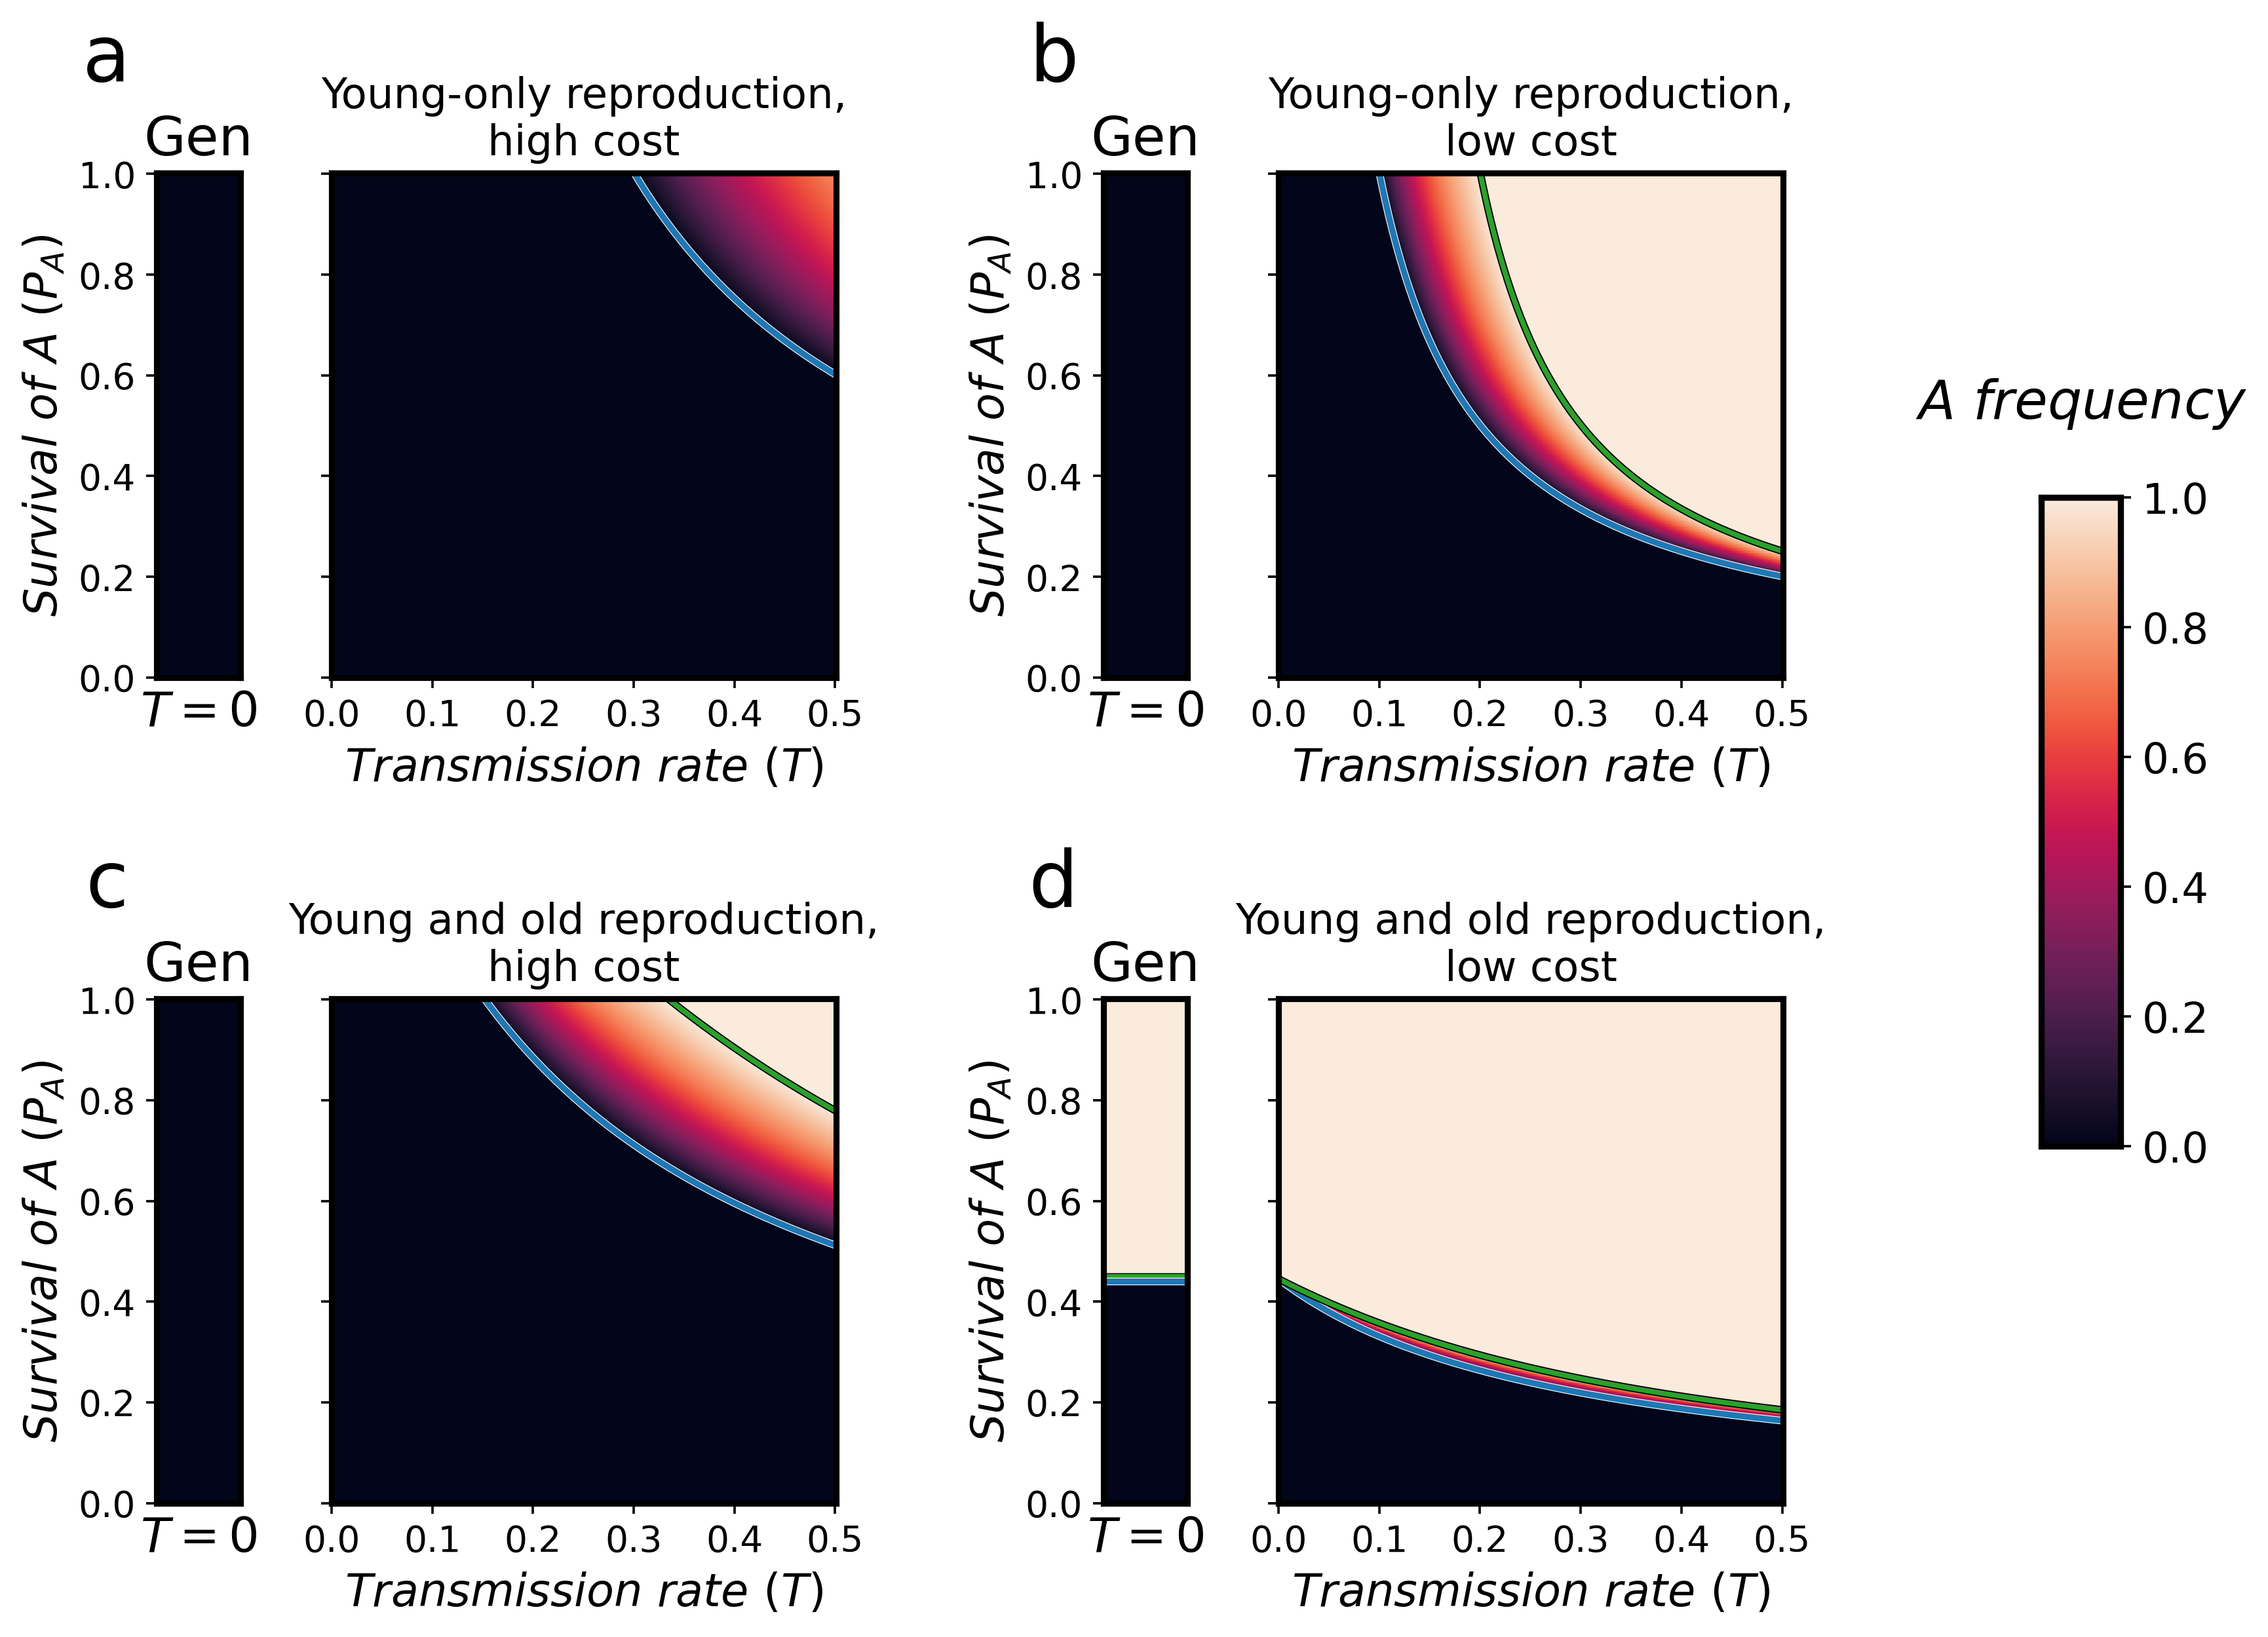

In [16]:
# ============================================================
# Figure 2 results
# ============================================================

fig2_data = {}

for panel_id in ("a", "b", "c", "d"):
    fig2_data[panel_id] = prepare_figure_data(
        matrix=fig2_matrices[panel_id],
        model_params=fig2_params[panel_id],
        x_name="T",
        x_axis=fig2_T,
        y_name="pA",
        y_axis=fig2_pA,
    )

# ============================================================
# Figure 2 panels
# ============================================================

fig2_panels = {
    "a": build_panel(
        data=fig2_data["a"],
        config={
            "title": "Young-only reproduction,\nhigh cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "b": build_panel(
        data=fig2_data["b"],
        config={
            "title": "Young-only reproduction,\nlow cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "c": build_panel(
        data=fig2_data["c"],
        config={
            "title": "Young and old reproduction,\nhigh cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),

    "d": build_panel(
        data=fig2_data["d"],
        config={
            "title": "Young and old reproduction,\nlow cost",
        },
        overlay_function=symmetric_theory_overlay,
    ),
}

# ============================================================
# Plot Figure 2
# ============================================================

fig2, fig2_axes, fig2_colorbar = plot_four_panel_figure(
    panels=fig2_panels,
    show_gene_strips=True,
    gene_overlays={
        "c": symmetric_gene_theory_overlay,
        "d": symmetric_gene_theory_overlay,
    },
    dpi=330,
)

## Recompute Figure 3

Figure 3 considers asymmetric transmission rates, expressed as the ratio $T_A/T_B$, with $T_B = 0.2$.

Each panel is computed over a $600 \times 600$ parameter grid spanning:

- $T_A/T_B = 0$ to $1$
- $P_A = 0$ to $1$

Panels a and b are evaluated sequentially. Panels c and d require the more computationally intensive polymorphism calculations and are evaluated in parallel.

In [19]:
# ============================================================
# Figure 3 parameter grid
# ============================================================

# Number of parameter values along each axis.
# The published figure was computed at 600 x 600 resolution.
N_POINTS = 600

fig3_ratio = np.linspace(0.0, 1.0, N_POINTS)
fig3_pA = np.linspace(0.0, 1.0, N_POINTS)


# ============================================================
# Figure 3 model parameters
# ============================================================

fig3_params = {
    "a": {
        "tA": 0.0,
        "tB": 0.2,
        "mA1": 2.0,
        "mA2": 0.0,
        "mB1": 2.0,
        "mB2": 0.0,
        "pA": 0.0,
    },

    "b": {
        "tA": 0.0,
        "tB": 0.2,
        "mA1": 1.8,
        "mA2": 0.0,
        "mB1": 2.0,
        "mB2": 0.0,
        "pA": 0.0,
    },

    "c": {
        "tA": 0.0,
        "tB": 0.2,
        "mA1": 2.0,
        "mA2": 0.5,
        "mB1": 2.0,
        "mB2": 0.5,
        "pA": 0.0,
    },

    "d": {
        "tA": 0.0,
        "tB": 0.2,
        "mA1": 1.8,
        "mA2": 0.45,
        "mB1": 2.0,
        "mB2": 0.5,
        "pA": 0.0,
    },
}

In [20]:
# ============================================================
# Compute Figure 3
# ============================================================

fig3_matrices = {}

# Panel a
fig3_matrices["a"] = parameter_sweep(
    model_params=fig3_params["a"],
    x_name="ratio_tA_tB",
    x_axis=fig3_ratio,
    y_name="pA",
    y_axis=fig3_pA,
)

# Panel b
fig3_matrices["b"] = parameter_sweep(
    model_params=fig3_params["b"],
    x_name="ratio_tA_tB",
    x_axis=fig3_ratio,
    y_name="pA",
    y_axis=fig3_pA,
)

# Panel c
fig3_matrices["c"] = parameter_sweep_parallel(
    model_params=fig3_params["c"],
    x_name="ratio_tA_tB",
    x_axis=fig3_ratio,
    y_name="pA",
    y_axis=fig3_pA,
)

# Panel d
fig3_matrices["d"] = parameter_sweep_parallel(
    model_params=fig3_params["d"],
    x_name="ratio_tA_tB",
    x_axis=fig3_ratio,
    y_name="pA",
    y_axis=fig3_pA,
)

Parameter sweep: 100%|██████████████████████████████████████| 360000/360000 [41:49<00:00, 143.48it/s]


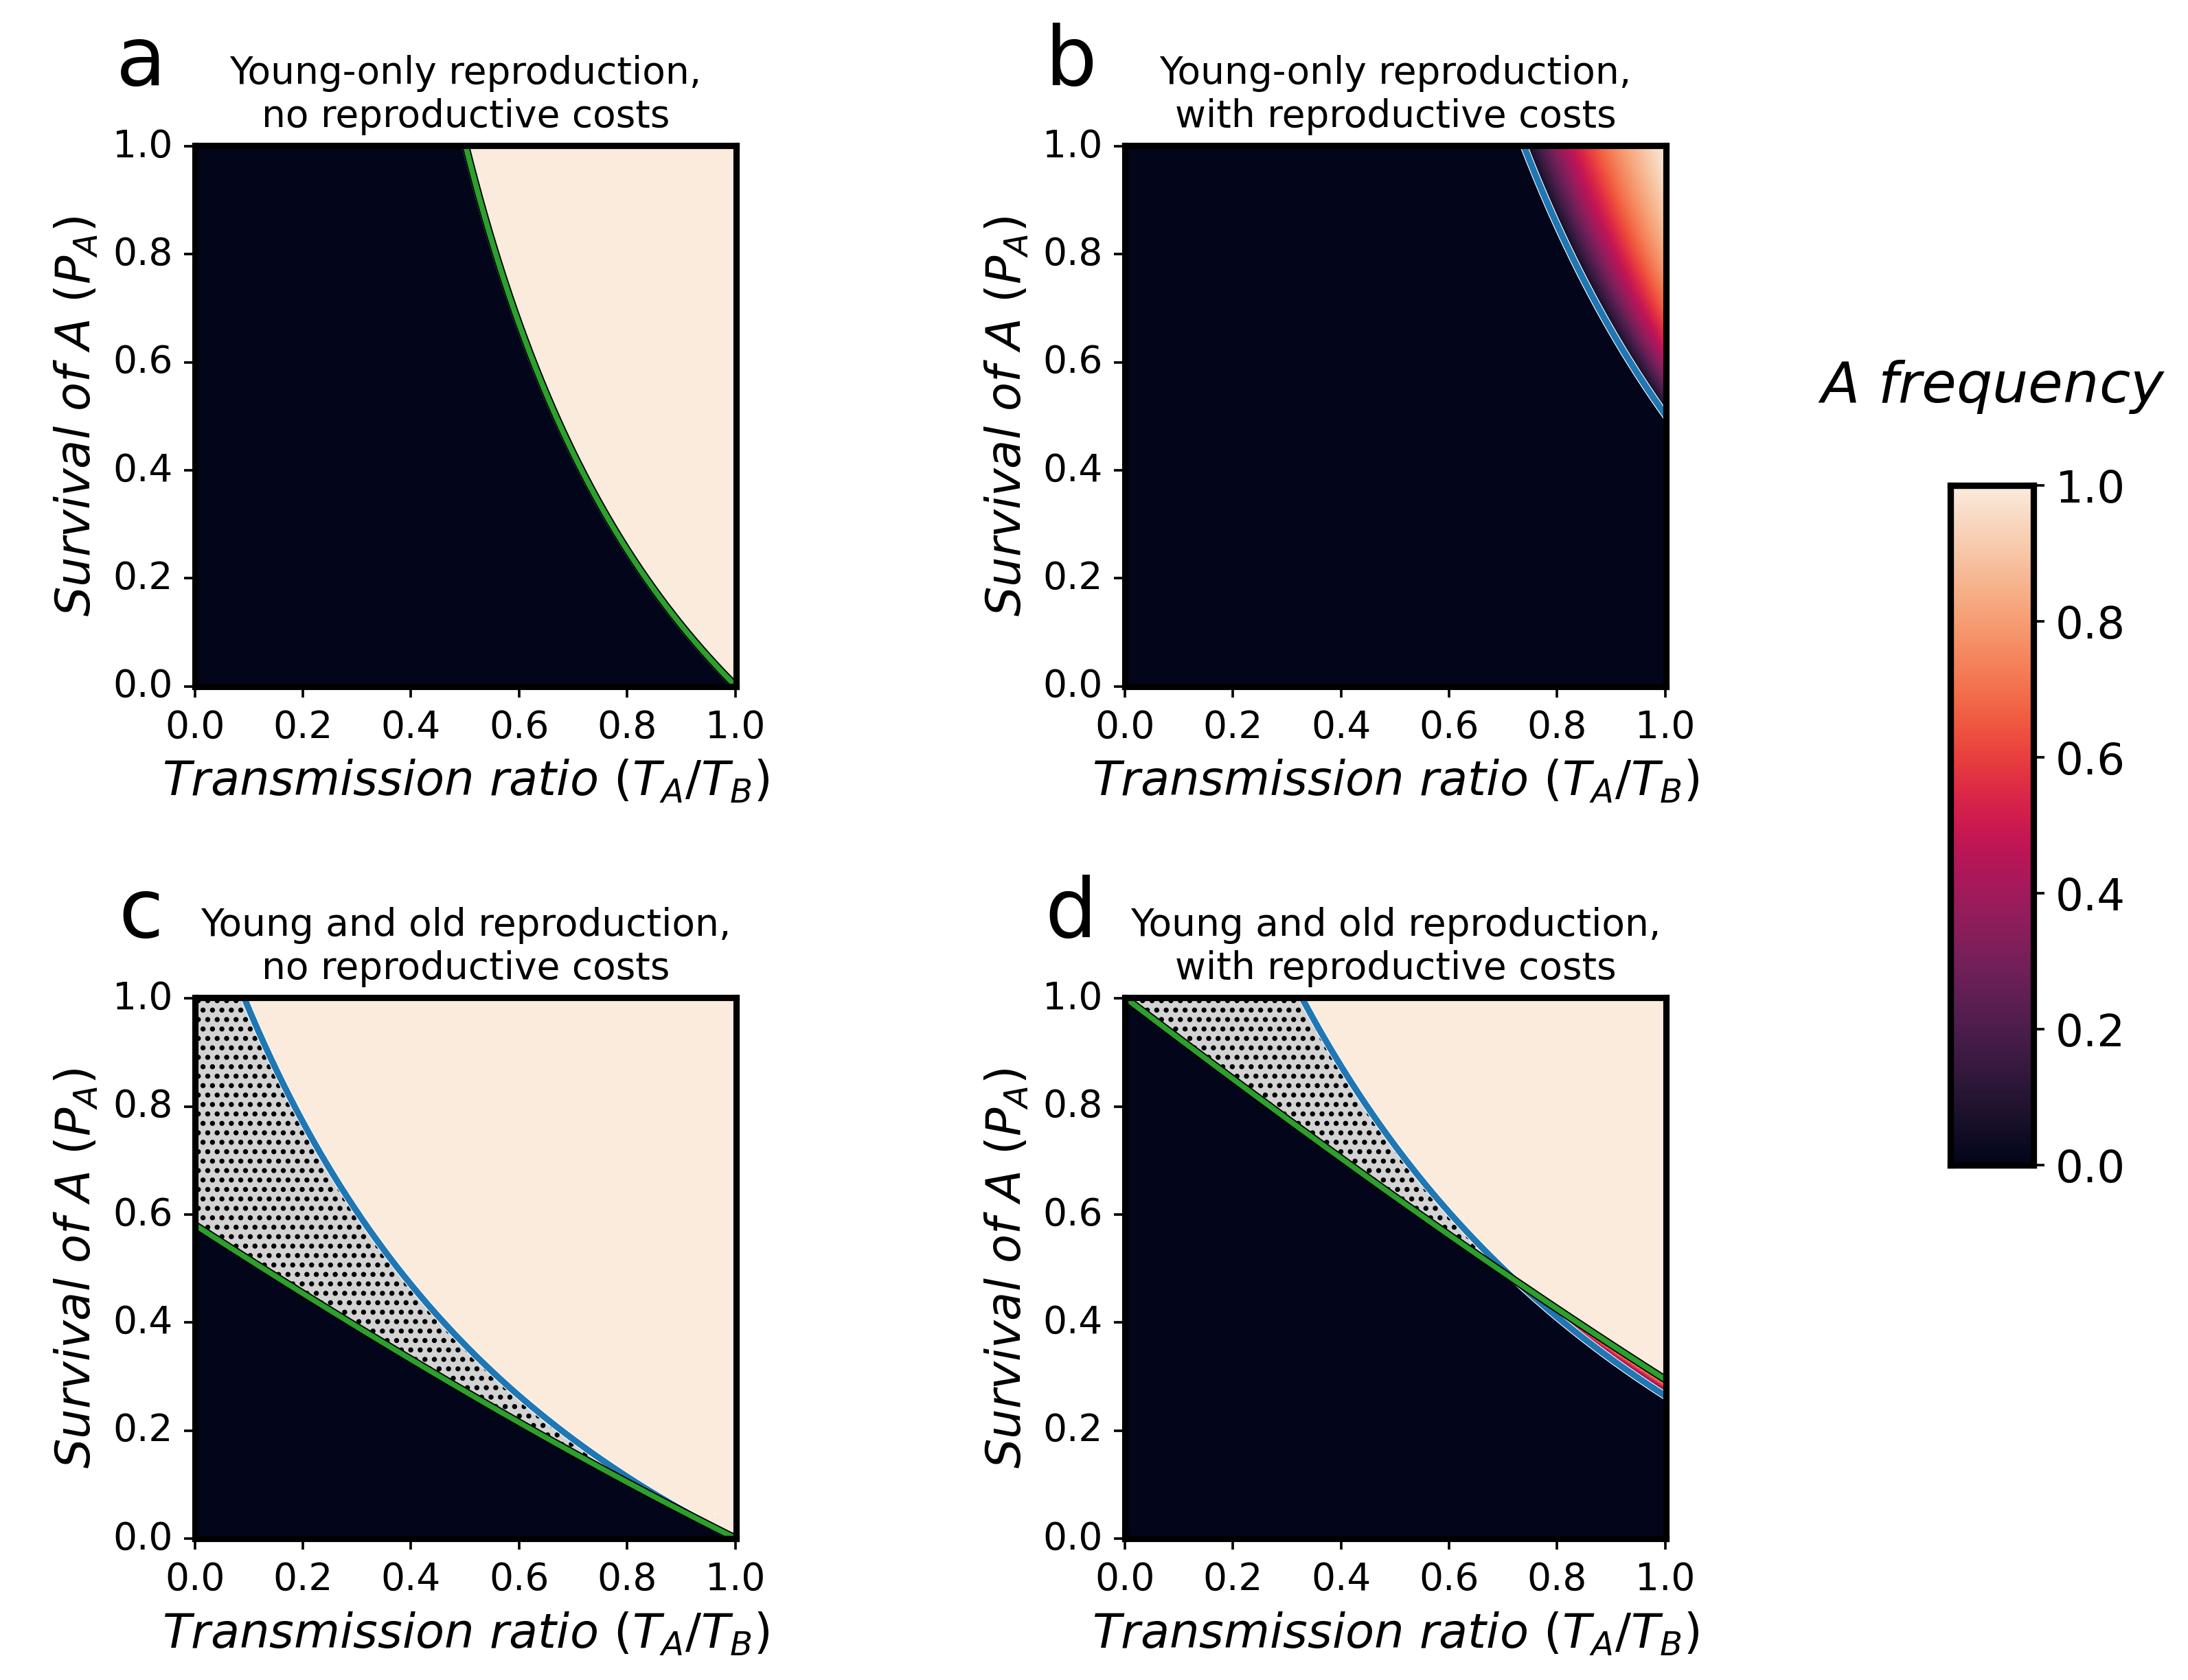

In [21]:
# ============================================================
# Figure 3 results
# ============================================================

fig3_data = {}

for panel_id in ("a", "b", "c", "d"):
    fig3_data[panel_id] = prepare_figure_data(
        matrix=fig3_matrices[panel_id],
        model_params=fig3_params[panel_id],
        x_name="ratio_tA_tB",
        x_axis=fig3_ratio,
        y_name="pA",
        y_axis=fig3_pA,
    )

# ============================================================
# Figure 3 panels
# ============================================================

fig3_panels = {
    "a": build_panel(
        data=fig3_data["a"],
        config={
            "title": "Young-only reproduction,\nno reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "b": build_panel(
        data=fig3_data["b"],
        config={
            "title": "Young-only reproduction,\nwith reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "c": build_panel(
        data=fig3_data["c"],
        config={
            "title": "Young and old reproduction,\nno reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),

    "d": build_panel(
        data=fig3_data["d"],
        config={
            "title": "Young and old reproduction,\nwith reproductive costs",
            "title_fontsize": 12,
        },
        overlay_function=asymmetric_theory_overlay,
    ),
}


# ============================================================
# Plot Figure 3
# ============================================================

fig3, fig3_axes, fig3_colorbar = plot_four_panel_figure(
    panels=fig3_panels,
    show_gene_strips=False,
    dpi=330,
)